# CS2 Snapshot Feature Engineering

In [1]:
from awpy import Demo
import polars as pl
import math
import ast
import random
from typing import Any, Dict, List

DEMO_PATH = "unity-vs-minlate-m1-mirage.dem"
TICKS_PER_SECOND = 64

dem = Demo(DEMO_PATH, verbose=True)
dem.parse()

player_state_df = dem.parse_ticks([
    "X", "Y", "Z",
    "health",
    "is_alive",
    "armor_value",
    "has_helmet",
    "has_defuser",
    "balance",
    "start_balance",
    "total_cash_spent",
    "cash_spent_this_round",
    "round_start_equip_value",
    "current_equip_value",
    "inventory",
    "flash_duration",
    "flash_max_alpha",
    "molotov_damage_time",
    "last_place_name",
    "pitch",
    "yaw",
    "velocity_X",
    "velocity_Y",
    "velocity_Z",
    "is_scoped",
    "is_walking",
    "is_defusing",
    "duck_amount",
    "shots_fired",
    "in_bomb_zone",
    "which_bomb_zone",
    "active_weapon",
    "steamid",
    "name",
    "round_num",
    "team_num"
])

print(dem.rounds.shape)
print(player_state_df.shape)
print(dem.smokes.shape, dem.infernos.shape, dem.grenades.shape, dem.kills.shape, dem.damages.shape, dem.bomb.shape)

2026-04-05 15:21:35.024 | DEBUG    | awpy.demo:parse:220 - Starting to parse unity-vs-minlate-m1-mirage.dem
2026-04-05 15:21:44.731 | SUCCESS  | awpy.demo:parse:271 - Finished parsing unity-vs-minlate-m1-mirage.dem, took 9.71 seconds
(24, 9)
(2254116, 36)
(159, 15) (128, 15) (2771908, 9) (152, 47) (613, 27) (144, 9)


In [2]:
def safe_sum(df: pl.DataFrame, col: str) -> float:
    if col not in df.columns or df.height == 0:
        return 0.0
    value = df.select(pl.col(col).sum()).item()
    return float(value) if value is not None else 0.0


def safe_mean(df: pl.DataFrame, col: str) -> float:
    if col not in df.columns or df.height == 0:
        return 0.0
    value = df.select(pl.col(col).mean()).item()
    return float(value) if value is not None else 0.0


def safe_nunique(df: pl.DataFrame, col: str) -> int:
    if col not in df.columns or df.height == 0:
        return 0
    value = df.select(pl.col(col).n_unique()).item()
    return int(value) if value is not None else 0


def safe_count_true(df: pl.DataFrame, col: str) -> int:
    if col not in df.columns or df.height == 0:
        return 0
    return df.filter(pl.col(col) == True).height


def normalize_inventory_value(inv: Any) -> List[str]:
    if inv is None:
        return []
    if isinstance(inv, list):
        return [str(x).lower() for x in inv]
    raw = str(inv).strip()
    if raw == "" or raw.lower() in {"none", "null", "nan"}:
        return []
    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, list):
            return [str(x).lower() for x in parsed]
    except Exception:
        pass
    return [part.strip().lower() for part in raw.split(",") if part.strip()]


def inventory_counts(items: List[str]) -> Dict[str, int]:
    smoke = 0
    flash = 0
    he = 0
    molly = 0
    bomb = 0
    for item in items:
        if "smoke" in item:
            smoke += 1
        if "flash" in item:
            flash += 1
        if "hegrenade" in item or item.endswith("he"):
            he += 1
        if "molotov" in item or "incendiary" in item:
            molly += 1
        if "c4" in item or item == "bomb":
            bomb += 1
    return {
        "smoke": smoke,
        "flash": flash,
        "he": he,
        "molly": molly,
        "bomb": bomb,
        "total_utility": smoke + flash + he + molly,
    }


SECONDARY_WEAPON_TOKENS = [
    "glock", "usp-s", "usp", "p2000", "p250", "fiveseven", "five-seven",
    "tec-9", "tec9", "cz75", "cz75-auto", "dual berettas", "elite",
    "deagle", "desert eagle", "r8 revolver",
]


def is_utility_item(item: str) -> bool:
    return any(token in item for token in ["flash", "smoke", "molotov", "incendiary", "hegrenade", "decoy"])


def is_secondary_weapon(item: str) -> bool:
    return any(token in item for token in SECONDARY_WEAPON_TOKENS)


def is_primary_weapon(item: str) -> bool:
    if item == "" or is_utility_item(item) or is_secondary_weapon(item):
        return False
    if any(token in item for token in ["knife", "bayonet", "karambit", "dagger", "c4", "bomb", "zeus"]):
        return False
    return True


def extract_loadout(items: List[str]) -> Dict[str, Any]:
    primary = ""
    secondary = ""
    for item in items:
        if primary == "" and is_primary_weapon(item):
            primary = item
        if secondary == "" and is_secondary_weapon(item):
            secondary = item
    return {
        "primary_weapon": primary,
        "secondary_weapon": secondary,
    }


def empty_player_slot(slot_prefix: str) -> Dict[str, Any]:
    return {
        f"{slot_prefix}_name": "",
        f"{slot_prefix}_steamid": 0,
        f"{slot_prefix}_alive": 0,
        f"{slot_prefix}_hp": 0.0,
        f"{slot_prefix}_armor": 0.0,
        f"{slot_prefix}_has_helmet": 0,
        f"{slot_prefix}_has_defuser": 0,
        f"{slot_prefix}_is_scoped": 0,
        f"{slot_prefix}_is_walking": 0,
        f"{slot_prefix}_duck_amount": 0.0,
        f"{slot_prefix}_flash_duration": 0.0,
        f"{slot_prefix}_shots_fired": 0.0,
        f"{slot_prefix}_X": 0.0,
        f"{slot_prefix}_Y": 0.0,
        f"{slot_prefix}_place": "MISSING",
        f"{slot_prefix}_primary_weapon": "",
        f"{slot_prefix}_secondary_weapon": "",
        f"{slot_prefix}_smoke": 0,
        f"{slot_prefix}_flash": 0,
        f"{slot_prefix}_he": 0,
        f"{slot_prefix}_molly": 0,
        f"{slot_prefix}_utility_total": 0,
        f"{slot_prefix}_has_bomb": 0,
    }


def build_player_slot_features(player_row: Dict[str, Any], slot_prefix: str) -> Dict[str, Any]:
    base = empty_player_slot(slot_prefix)
    if not player_row:
        return base

    items = normalize_inventory_value(player_row.get("inventory"))
    counts = inventory_counts(items)
    loadout = extract_loadout(items)
    place_bucket = infer_detailed_place_bucket(player_row.get("last_place_name"))
    is_alive = bool(player_row.get("is_alive", False)) if "is_alive" in player_row else float(player_row.get("health", 0.0) or 0.0) > 0

    return {
        **base,
        f"{slot_prefix}_name": str(player_row.get("name") or ""),
        f"{slot_prefix}_steamid": int(player_row.get("steamid") or 0),
        f"{slot_prefix}_alive": 1 if is_alive else 0,
        f"{slot_prefix}_hp": float(player_row.get("health") or 0.0),
        f"{slot_prefix}_armor": float(player_row.get("armor_value") or 0.0),
        f"{slot_prefix}_has_helmet": 1 if bool(player_row.get("has_helmet", False)) else 0,
        f"{slot_prefix}_has_defuser": 1 if bool(player_row.get("has_defuser", False)) else 0,
        f"{slot_prefix}_is_scoped": 1 if bool(player_row.get("is_scoped", False)) else 0,
        f"{slot_prefix}_is_walking": 1 if bool(player_row.get("is_walking", False)) else 0,
        f"{slot_prefix}_duck_amount": float(player_row.get("duck_amount") or 0.0),
        f"{slot_prefix}_flash_duration": float(player_row.get("flash_duration") or 0.0),
        f"{slot_prefix}_shots_fired": float(player_row.get("shots_fired") or 0.0),
        f"{slot_prefix}_X": float(player_row.get("X") or 0.0),
        f"{slot_prefix}_Y": float(player_row.get("Y") or 0.0),
        f"{slot_prefix}_place": place_bucket,
        f"{slot_prefix}_primary_weapon": loadout["primary_weapon"],
        f"{slot_prefix}_secondary_weapon": loadout["secondary_weapon"],
        f"{slot_prefix}_smoke": counts["smoke"],
        f"{slot_prefix}_flash": counts["flash"],
        f"{slot_prefix}_he": counts["he"],
        f"{slot_prefix}_molly": counts["molly"],
        f"{slot_prefix}_utility_total": counts["total_utility"],
        f"{slot_prefix}_has_bomb": 1 if counts["bomb"] > 0 else 0,
    }


def build_player_snapshot_features(tick_rows: pl.DataFrame, t_roster: List[int], ct_roster: List[int]) -> Dict[str, Any]:
    row_map = {int(row["steamid"]): row for row in tick_rows.to_dicts() if row.get("steamid") is not None}
    out = {}
    for idx, steamid in enumerate(t_roster, start=1):
        out.update(build_player_slot_features(row_map.get(int(steamid), {}), f"T{idx}"))
    for idx, steamid in enumerate(ct_roster, start=1):
        out.update(build_player_slot_features(row_map.get(int(steamid), {}), f"CT{idx}"))
    return out


def ensure_player_state_columns(df: pl.DataFrame, rounds_df: pl.DataFrame) -> pl.DataFrame:
    if "side" in df.columns:
        out = df.with_columns(pl.col("side").cast(pl.Utf8).str.to_uppercase().alias("side"))
    else:
        out = df.with_columns(
            pl.when(pl.col("team_num") == 2)
            .then(pl.lit("T"))
            .when(pl.col("team_num") == 3)
            .then(pl.lit("CT"))
            .otherwise(pl.lit(None))
            .alias("side")
        )

    if "round_num" not in out.columns:
        out = out.with_columns(pl.lit(None).cast(pl.Int64).alias("round_num"))
        for row in rounds_df.select(["round_num", "start", "end"]).to_dicts():
            out = out.with_columns(
                pl.when(
                    (pl.col("tick") >= int(row["start"])) &
                    (pl.col("tick") <= int(row["end"]))
                )
                .then(pl.lit(int(row["round_num"])))
                .otherwise(pl.col("round_num"))
                .alias("round_num")
            )

    return out.filter(pl.col("round_num").is_not_null())



def prepare_grenades(grenades_df: pl.DataFrame, player_state_df: pl.DataFrame) -> pl.DataFrame:
    side_map = (
        player_state_df.select(["round_num", "steamid", "side"])
        .drop_nulls()
        .unique()
        .rename({"steamid": "thrower_steamid", "side": "thrower_side"})
    )
    return grenades_df.join(side_map, on=["round_num", "thrower_steamid"], how="left")


def infer_site_bucket(place: Any) -> str:
    text = str(place or "").lower().replace(" ", "")
    if any(token in text for token in ["bombsitea", "aramp", "palace", "jungle", "ticket", "stairs", "connector"]):
        return "A"
    if any(token in text for token in ["bombsiteb", "apartments", "apps", "market", "bench", "van", "shortb", "kitchen"]):
        return "B"
    if any(token in text for token in ["mid", "middle", "topofmid", "catwalk", "window", "underpass"]):
        return "MID"
    return "OTHER"


MIRAGE_PLACE_BUCKETS = {
    "TSPAWN": ["tspawn"],
    "CTSPAWN": ["ctspawn"],
    "A_SITE": ["bombsitea", "truck", "default", "firebox"],
    "A_RAMP": ["tramp"],
    "PALACE": ["palaceinterior", "palacealley"],
    "MID": ["middle", "topofmid"],
    "UNDERPASS": ["underpass"],
    "CONNECTOR": ["connector"],
    "CATWALK": ["catwalk", "short"],
    "WINDOW": ["snipersnest", "window"],
    "JUNGLE": ["jungle"],
    "STAIRS": ["stairs"],
    "B_SITE": ["bombsiteb", "siteb"],
    "APPS": ["apartments", "house", "kitchen"],
    "MARKET": ["market", "shop"],
    "BACK_ALLEY": ["backalley", "sidealley"],
    "LADDER": ["ladder", "scaffolding"],
}


def infer_detailed_place_bucket(place: Any) -> str:
    text = str(place or "").lower().replace(" ", "")
    for bucket, tokens in MIRAGE_PLACE_BUCKETS.items():
        if any(token in text for token in tokens):
            return bucket
    return "OTHER"


# Mirage site boundaries estimated from BombsiteA/B player coordinates in this demo.
SITE_BOUNDS = {
    "A": {
        "x_min": -1250.0,
        "x_max": 250.0,
        "y_min": -2700.0,
        "y_max": -1200.0,
    },
    "B": {
        "x_min": -2700.0,
        "x_max": -950.0,
        "y_min": -450.0,
        "y_max": 750.0,
    },
}


def site_coordinate_filter(site: str) -> pl.Expr:
    bounds = SITE_BOUNDS[site]
    return (
        (pl.col("X") >= bounds["x_min"])
        & (pl.col("X") <= bounds["x_max"])
        & (pl.col("Y") >= bounds["y_min"])
        & (pl.col("Y") <= bounds["y_max"])
    )


def aggregate_team_state(team_df: pl.DataFrame, prefix: str) -> Dict[str, Any]:
    base = {
        f"{prefix}_alive": 0,
        f"{prefix}_hp_sum": 0.0,
        f"{prefix}_armor_sum": 0.0,
        f"{prefix}_money_sum": 0.0,
        f"{prefix}_start_balance_sum": 0.0,
        f"{prefix}_cash_spent_round_sum": 0.0,
        f"{prefix}_equip_value_sum": 0.0,
        f"{prefix}_round_start_equip_sum": 0.0,
        f"{prefix}_helmet_count": 0,
        f"{prefix}_defuser_count": 0,
        f"{prefix}_scoped_count": 0,
        f"{prefix}_walking_count": 0,
        f"{prefix}_defusing_count": 0,
        f"{prefix}_bomb_zone_count": 0,
        f"{prefix}_flashed_players": 0,
        f"{prefix}_flash_duration_sum": 0.0,
        f"{prefix}_flash_alpha_mean": 0.0,
        f"{prefix}_burning_players": 0,
        f"{prefix}_duck_amount_mean": 0.0,
        f"{prefix}_shots_fired_sum": 0.0,
        f"{prefix}_velocity_mean": 0.0,
        f"{prefix}_smoke_inv": 0,
        f"{prefix}_flash_inv": 0,
        f"{prefix}_he_inv": 0,
        f"{prefix}_molly_inv": 0,
        f"{prefix}_utility_inv": 0,
        f"{prefix}_bomb_carrier_alive": 0,
        f"{prefix}_unique_places": 0,
        f"{prefix}_players_A": 0,
        f"{prefix}_players_B": 0,
        f"{prefix}_players_MID": 0,
        f"{prefix}_players_TSPAWN": 0,
        f"{prefix}_players_CTSPAWN": 0,
        f"{prefix}_players_A_SITE": 0,
        f"{prefix}_players_A_RAMP": 0,
        f"{prefix}_players_PALACE": 0,
        f"{prefix}_players_UNDERPASS": 0,
        f"{prefix}_players_CONNECTOR": 0,
        f"{prefix}_players_CATWALK": 0,
        f"{prefix}_players_WINDOW": 0,
        f"{prefix}_players_JUNGLE": 0,
        f"{prefix}_players_STAIRS": 0,
        f"{prefix}_players_B_SITE": 0,
        f"{prefix}_players_APPS": 0,
        f"{prefix}_players_MARKET": 0,
        f"{prefix}_players_BACK_ALLEY": 0,
        f"{prefix}_players_LADDER": 0,
        f"{prefix}_players_OTHER": 0,
        f"{prefix}_mean_X": 0.0,
        f"{prefix}_mean_Y": 0.0,
        f"{prefix}_spread_xy": 0.0,
    }

    if team_df.height == 0:
        return base

    smoke_inv = 0
    flash_inv = 0
    he_inv = 0
    molly_inv = 0
    bomb_alive = 0

    if "inventory" in team_df.columns:
        for row in team_df.select("inventory").to_dicts():
            counts = inventory_counts(normalize_inventory_value(row["inventory"]))
            smoke_inv += counts["smoke"]
            flash_inv += counts["flash"]
            he_inv += counts["he"]
            molly_inv += counts["molly"]
            bomb_alive += counts["bomb"]

    mean_x = safe_mean(team_df, "X")
    mean_y = safe_mean(team_df, "Y")
    velocity_df = team_df.with_columns((((pl.col("velocity_X") ** 2) + (pl.col("velocity_Y") ** 2) + (pl.col("velocity_Z") ** 2)) ** 0.5).alias("velocity_mag"))
    spread_df = team_df.with_columns((((pl.col("X") - mean_x) ** 2 + (pl.col("Y") - mean_y) ** 2) ** 0.5).alias("dist_to_centroid"))

    place_col = "last_place_name" if "last_place_name" in team_df.columns else None
    buckets = []
    detailed_buckets = []
    if place_col is not None:
        buckets = [infer_site_bucket(row[place_col]) for row in team_df.select(place_col).to_dicts()]
        detailed_buckets = [infer_detailed_place_bucket(row[place_col]) for row in team_df.select(place_col).to_dicts()]

    detailed_counts = {bucket: 0 for bucket in MIRAGE_PLACE_BUCKETS}
    detailed_counts["OTHER"] = 0
    for bucket in detailed_buckets:
        detailed_counts[bucket] = detailed_counts.get(bucket, 0) + 1

    return {
        f"{prefix}_alive": team_df.height,
        f"{prefix}_hp_sum": safe_sum(team_df, "health"),
        f"{prefix}_armor_sum": safe_sum(team_df, "armor_value"),
        f"{prefix}_money_sum": safe_sum(team_df, "balance"),
        f"{prefix}_start_balance_sum": safe_sum(team_df, "start_balance"),
        f"{prefix}_cash_spent_round_sum": safe_sum(team_df, "cash_spent_this_round"),
        f"{prefix}_equip_value_sum": safe_sum(team_df, "current_equip_value"),
        f"{prefix}_round_start_equip_sum": safe_sum(team_df, "round_start_equip_value"),
        f"{prefix}_helmet_count": safe_count_true(team_df, "has_helmet"),
        f"{prefix}_defuser_count": safe_count_true(team_df, "has_defuser"),
        f"{prefix}_scoped_count": safe_count_true(team_df, "is_scoped"),
        f"{prefix}_walking_count": safe_count_true(team_df, "is_walking"),
        f"{prefix}_defusing_count": safe_count_true(team_df, "is_defusing"),
        f"{prefix}_bomb_zone_count": safe_count_true(team_df, "in_bomb_zone"),
        f"{prefix}_flashed_players": team_df.filter(pl.col("flash_duration") > 0).height if "flash_duration" in team_df.columns else 0,
        f"{prefix}_flash_duration_sum": safe_sum(team_df, "flash_duration"),
        f"{prefix}_flash_alpha_mean": safe_mean(team_df, "flash_max_alpha"),
        f"{prefix}_burning_players": team_df.filter(pl.col("molotov_damage_time") > 0).height if "molotov_damage_time" in team_df.columns else 0,
        f"{prefix}_duck_amount_mean": safe_mean(team_df, "duck_amount"),
        f"{prefix}_shots_fired_sum": safe_sum(team_df, "shots_fired"),
        f"{prefix}_velocity_mean": safe_mean(velocity_df, "velocity_mag"),
        f"{prefix}_smoke_inv": smoke_inv,
        f"{prefix}_flash_inv": flash_inv,
        f"{prefix}_he_inv": he_inv,
        f"{prefix}_molly_inv": molly_inv,
        f"{prefix}_utility_inv": smoke_inv + flash_inv + he_inv + molly_inv,
        f"{prefix}_bomb_carrier_alive": 1 if bomb_alive > 0 else 0,
        f"{prefix}_unique_places": safe_nunique(team_df, place_col) if place_col is not None else 0,
        f"{prefix}_players_A": sum(bucket == "A" for bucket in buckets),
        f"{prefix}_players_B": sum(bucket == "B" for bucket in buckets),
        f"{prefix}_players_MID": sum(bucket == "MID" for bucket in buckets),
        f"{prefix}_players_TSPAWN": detailed_counts["TSPAWN"],
        f"{prefix}_players_CTSPAWN": detailed_counts["CTSPAWN"],
        f"{prefix}_players_A_SITE": detailed_counts["A_SITE"],
        f"{prefix}_players_A_RAMP": detailed_counts["A_RAMP"],
        f"{prefix}_players_PALACE": detailed_counts["PALACE"],
        f"{prefix}_players_UNDERPASS": detailed_counts["UNDERPASS"],
        f"{prefix}_players_CONNECTOR": detailed_counts["CONNECTOR"],
        f"{prefix}_players_CATWALK": detailed_counts["CATWALK"],
        f"{prefix}_players_WINDOW": detailed_counts["WINDOW"],
        f"{prefix}_players_JUNGLE": detailed_counts["JUNGLE"],
        f"{prefix}_players_STAIRS": detailed_counts["STAIRS"],
        f"{prefix}_players_B_SITE": detailed_counts["B_SITE"],
        f"{prefix}_players_APPS": detailed_counts["APPS"],
        f"{prefix}_players_MARKET": detailed_counts["MARKET"],
        f"{prefix}_players_BACK_ALLEY": detailed_counts["BACK_ALLEY"],
        f"{prefix}_players_LADDER": detailed_counts["LADDER"],
        f"{prefix}_players_OTHER": detailed_counts["OTHER"],
        f"{prefix}_mean_X": mean_x,
        f"{prefix}_mean_Y": mean_y,
        f"{prefix}_spread_xy": safe_mean(spread_df, "dist_to_centroid"),
    }


def utility_damage(df: pl.DataFrame, start_tick: int, end_tick: int, side: str) -> float:
    if df.height == 0:
        return 0.0
    subset = df.filter(
        (pl.col("tick") >= start_tick)
        & (pl.col("tick") <= end_tick)
        & (pl.col("attacker_side").cast(pl.Utf8).str.to_uppercase() == side)
    )
    subset = subset.filter(
        pl.col("weapon").cast(pl.Utf8).str.to_lowercase().fill_null("").map_elements(
            lambda w: any(token in w for token in ["hegrenade", "inferno", "molotov", "incendiary"]),
            return_dtype=pl.Boolean,
        )
    )
    dmg_col = "dmg_health_real" if "dmg_health_real" in subset.columns else "dmg_health"
    return safe_sum(subset, dmg_col)


def damage_by_side(df: pl.DataFrame, start_tick: int, end_tick: int, side: str) -> float:
    if df.height == 0:
        return 0.0
    subset = df.filter(
        (pl.col("tick") >= start_tick)
        & (pl.col("tick") <= end_tick)
        & (pl.col("attacker_side").cast(pl.Utf8).str.to_uppercase() == side)
    )
    dmg_col = "dmg_health_real" if "dmg_health_real" in subset.columns else "dmg_health"
    return safe_sum(subset, dmg_col)


def kills_by_side(df: pl.DataFrame, start_tick: int, end_tick: int, side: str) -> int:
    if df.height == 0:
        return 0
    subset = df.filter(
        (pl.col("tick") >= start_tick)
        & (pl.col("tick") <= end_tick)
        & (pl.col("attacker_side").cast(pl.Utf8).str.to_uppercase() == side)
    )
    return subset.height


def bomb_events_recent(df: pl.DataFrame, start_tick: int, end_tick: int) -> int:
    if df.height == 0:
        return 0
    return df.filter((pl.col("tick") >= start_tick) & (pl.col("tick") <= end_tick)).height


def count_active_utility(df: pl.DataFrame, tick: int, side: str) -> int:
    if df.height == 0:
        return 0
    return df.filter(
        (pl.col("start_tick") <= tick)
        & (pl.col("end_tick") >= tick)
        & (pl.col("thrower_side").cast(pl.Utf8).str.to_uppercase() == side)
    ).height


def count_active_near_point(df: pl.DataFrame, tick: int, side: str, x: float, y: float, radius: float = 400.0) -> int:
    if df.height == 0:
        return 0
    subset = df.filter(
        (pl.col("start_tick") <= tick)
        & (pl.col("end_tick") >= tick)
        & (pl.col("thrower_side").cast(pl.Utf8).str.to_uppercase() == side)
    )
    if subset.height == 0:
        return 0
    return subset.filter(((pl.col("X") - x) ** 2 + (pl.col("Y") - y) ** 2) <= radius ** 2).height


def count_active_utility_in_site(df: pl.DataFrame, tick: int, side: str, site: str) -> int:
    if df.height == 0:
        return 0
    subset = df.filter(
        (pl.col("start_tick") <= tick)
        & (pl.col("end_tick") >= tick)
        & (pl.col("thrower_side").cast(pl.Utf8).str.to_uppercase() == side)
        & site_coordinate_filter(site)
    )
    return subset.height


def count_grenade_throws(grenades_df: pl.DataFrame, start_tick: int, end_tick: int, side: str, types: List[str]) -> int:
    if grenades_df.height == 0:
        return 0
    subset = grenades_df.filter(
        (pl.col("tick") >= start_tick)
        & (pl.col("tick") <= end_tick)
        & (pl.col("thrower_side").cast(pl.Utf8).str.to_uppercase() == side)
        & (pl.col("grenade_type").cast(pl.Utf8).str.to_lowercase().is_in([t.lower() for t in types]))
    )
    return subset.select(pl.col("entity_id").n_unique()).item() if subset.height > 0 else 0


def count_grenade_throws_in_site(grenades_df: pl.DataFrame, start_tick: int, end_tick: int, side: str, types: List[str], site: str) -> int:
    if grenades_df.height == 0:
        return 0
    subset = grenades_df.filter(
        (pl.col("tick") >= start_tick)
        & (pl.col("tick") <= end_tick)
        & (pl.col("thrower_side").cast(pl.Utf8).str.to_uppercase() == side)
        & (pl.col("grenade_type").cast(pl.Utf8).str.to_lowercase().is_in([t.lower() for t in types]))
        & pl.col("X").is_not_null()
        & pl.col("Y").is_not_null()
        & site_coordinate_filter(site)
    )
    return subset.select(pl.col("entity_id").n_unique()).item() if subset.height > 0 else 0


def mean_closest_enemy_distance(t_df: pl.DataFrame, ct_df: pl.DataFrame) -> Dict[str, float]:
    if t_df.height == 0 or ct_df.height == 0:
        return {
            "T_closest_enemy_dist": 0.0,
            "CT_closest_enemy_dist": 0.0,
            "closest_enemy_dist_diff": 0.0,
        }

    t_rows = t_df.select(["X", "Y"]).to_dicts()
    ct_rows = ct_df.select(["X", "Y"]).to_dicts()

    def mean_min_dist(src_rows, dst_rows):
        mins = []
        for src in src_rows:
            dists = [math.sqrt((float(src["X"]) - float(dst["X"])) ** 2 + (float(src["Y"]) - float(dst["Y"])) ** 2) for dst in dst_rows]
            mins.append(min(dists))
        return sum(mins) / len(mins) if mins else 0.0

    t_mean = mean_min_dist(t_rows, ct_rows)
    ct_mean = mean_min_dist(ct_rows, t_rows)
    return {
        "T_closest_enemy_dist": t_mean,
        "CT_closest_enemy_dist": ct_mean,
        "closest_enemy_dist_diff": ct_mean - t_mean,
    }


def build_snapshot_dataset(
    rounds_df: pl.DataFrame,
    player_state_df: pl.DataFrame,
    smokes_df: pl.DataFrame,
    infernos_df: pl.DataFrame,
    grenades_df: pl.DataFrame,
    kills_df: pl.DataFrame,
    damages_df: pl.DataFrame,
    bomb_df: pl.DataFrame,
    tick_step: int = 64,
) -> pl.DataFrame:
    player_state_df = ensure_player_state_columns(player_state_df, rounds_df)
    
    grenades_df = prepare_grenades(grenades_df, player_state_df)
    smokes_df = smokes_df.with_columns(pl.col("thrower_side").cast(pl.Utf8).str.to_uppercase())
    infernos_df = infernos_df.with_columns(pl.col("thrower_side").cast(pl.Utf8).str.to_uppercase())

    rows = []

    for round_row in rounds_df.to_dicts():
        round_num = int(round_row["round_num"])
        start_tick = int(round_row["start"])
        freeze_end = int(round_row.get("freeze_end", start_tick))
        end_tick = int(round_row["end"])
        ct_win = 1 if str(round_row["winner"]).strip().upper() == "CT" else 0

        round_players = player_state_df.filter(pl.col("round_num") == round_num)
        round_smokes = smokes_df.filter(pl.col("round_num") == round_num)
        round_infernos = infernos_df.filter(pl.col("round_num") == round_num)
        round_grenades = grenades_df.filter(pl.col("round_num") == round_num)
        round_kills = kills_df.filter(pl.col("round_num") == round_num)
        round_damages = damages_df.filter(pl.col("round_num") == round_num)
        round_bomb = bomb_df.filter(pl.col("round_num") == round_num)
        t_roster = [
            int(row["steamid"])
            for row in round_players
            .filter((pl.col("side") == "T") & pl.col("steamid").is_not_null())
            .select(["steamid", "name"])
            .unique()
            .sort(["name", "steamid"])
            .head(5)
            .to_dicts()
        ]
        ct_roster = [
            int(row["steamid"])
            for row in round_players
            .filter((pl.col("side") == "CT") & pl.col("steamid").is_not_null())
            .select(["steamid", "name"])
            .unique()
            .sort(["name", "steamid"])
            .head(5)
            .to_dicts()
        ]
        while len(t_roster) < 5:
            t_roster.append(-len(t_roster) - 1)
        while len(ct_roster) < 5:
            ct_roster.append(-len(ct_roster) - 101)

        for tick in range(start_tick, end_tick, tick_step):
            last_3s = max(start_tick, tick - 3 * TICKS_PER_SECOND)
            last_5s = max(start_tick, tick - 5 * TICKS_PER_SECOND)

            tick_rows = round_players.filter(pl.col("tick") == tick)
            alive_rows = tick_rows
            if "is_alive" in alive_rows.columns:
                alive_rows = alive_rows.filter(pl.col("is_alive") == True)
            else:
                alive_rows = alive_rows.filter(pl.col("health") > 0)

            t_alive = alive_rows.filter(pl.col("side") == "T")
            ct_alive = alive_rows.filter(pl.col("side") == "CT")

            t_state = aggregate_team_state(t_alive, "T")
            ct_state = aggregate_team_state(ct_alive, "CT")
            enemy_dist = mean_closest_enemy_distance(t_alive, ct_alive)

            t_damage_5s = damage_by_side(round_damages, last_5s, tick, "T")
            ct_damage_5s = damage_by_side(round_damages, last_5s, tick, "CT")
            t_util_damage_5s = utility_damage(round_damages, last_5s, tick, "T")
            ct_util_damage_5s = utility_damage(round_damages, last_5s, tick, "CT")
            player_snapshot_row = build_player_snapshot_features(tick_rows, t_roster, ct_roster)
            site_utility_row = {}
            for site in ["A", "B"]:
                for side in ["T", "CT"]:
                    prefix = f"{side}_{site}_site"
                    site_utility_row[f"{prefix}_active_smokes"] = count_active_utility_in_site(round_smokes, tick, side, site)
                    site_utility_row[f"{prefix}_active_infernos"] = count_active_utility_in_site(round_infernos, tick, side, site)
                    site_utility_row[f"{prefix}_smokes_last_5s"] = count_grenade_throws_in_site(round_grenades, last_5s, tick, side, ["CSmokeGrenade"], site)
                    site_utility_row[f"{prefix}_flashes_last_5s"] = count_grenade_throws_in_site(round_grenades, last_5s, tick, side, ["CFlashbang"], site)
                    site_utility_row[f"{prefix}_he_last_5s"] = count_grenade_throws_in_site(round_grenades, last_5s, tick, side, ["CHEGrenade"], site)
                    site_utility_row[f"{prefix}_mollies_last_5s"] = count_grenade_throws_in_site(round_grenades, last_5s, tick, side, ["CMolotovGrenade", "CIncendiaryGrenade"], site)

            row = {
                "round_num": round_num,
                "tick": tick,
                "seconds_in_round": (tick - start_tick) / TICKS_PER_SECOND,
                "seconds_since_freeze_end": max(0.0, (tick - freeze_end) / TICKS_PER_SECOND),
                "is_freeze_time": 1 if tick < freeze_end else 0,
                "bomb_planted": 1 if round_row.get("bomb_plant") is not None and tick >= int(round_row["bomb_plant"]) else 0,
                "bomb_events_last_5s": bomb_events_recent(round_bomb, last_5s, tick),
                **t_state,
                **ct_state,
                "alive_diff": ct_state["CT_alive"] - t_state["T_alive"],
                "hp_diff": ct_state["CT_hp_sum"] - t_state["T_hp_sum"],
                "armor_diff": ct_state["CT_armor_sum"] - t_state["T_armor_sum"],
                "money_diff": ct_state["CT_money_sum"] - t_state["T_money_sum"],
                "equip_diff": ct_state["CT_equip_value_sum"] - t_state["T_equip_value_sum"],
                "utility_inv_diff": ct_state["CT_utility_inv"] - t_state["T_utility_inv"],
                "flash_inv_diff": ct_state["CT_flash_inv"] - t_state["T_flash_inv"],
                "smoke_inv_diff": ct_state["CT_smoke_inv"] - t_state["T_smoke_inv"],
                "molly_inv_diff": ct_state["CT_molly_inv"] - t_state["T_molly_inv"],
                "spread_diff": ct_state["CT_spread_xy"] - t_state["T_spread_xy"],
                "centroid_distance_xy": math.sqrt((ct_state["CT_mean_X"] - t_state["T_mean_X"]) ** 2 + (ct_state["CT_mean_Y"] - t_state["T_mean_Y"]) ** 2),
                **enemy_dist,
                "T_damage_last_5s": t_damage_5s,
                "CT_damage_last_5s": ct_damage_5s,
                "damage_diff_last_5s": ct_damage_5s - t_damage_5s,
                "T_utility_damage_last_5s": t_util_damage_5s,
                "CT_utility_damage_last_5s": ct_util_damage_5s,
                "utility_damage_diff_last_5s": ct_util_damage_5s - t_util_damage_5s,
                "T_kills_last_3s": kills_by_side(round_kills, last_3s, tick, "T"),
                "CT_kills_last_3s": kills_by_side(round_kills, last_3s, tick, "CT"),
                "T_active_smokes": count_active_utility(round_smokes, tick, "T"),
                "CT_active_smokes": count_active_utility(round_smokes, tick, "CT"),
                "T_active_infernos": count_active_utility(round_infernos, tick, "T"),
                "CT_active_infernos": count_active_utility(round_infernos, tick, "CT"),
                "T_smokes_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "T", ["CSmokeGrenade"]),
                "CT_smokes_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "CT", ["CSmokeGrenade"]),
                "T_flashes_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "T", ["CFlashbang"]),
                "CT_flashes_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "CT", ["CFlashbang"]),
                "T_he_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "T", ["CHEGrenade"]),
                "CT_he_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "CT", ["CHEGrenade"]),
                "T_mollies_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "T", ["CMolotovGrenade", "CIncendiaryGrenade"]),
                "CT_mollies_last_5s": count_grenade_throws(round_grenades, last_5s, tick, "CT", ["CMolotovGrenade", "CIncendiaryGrenade"]),
                "T_smokes_used_total": count_grenade_throws(round_grenades, start_tick, tick, "T", ["CSmokeGrenade"]),
                "CT_smokes_used_total": count_grenade_throws(round_grenades, start_tick, tick, "CT", ["CSmokeGrenade"]),
                "T_flashes_used_total": count_grenade_throws(round_grenades, start_tick, tick, "T", ["CFlashbang"]),
                "CT_flashes_used_total": count_grenade_throws(round_grenades, start_tick, tick, "CT", ["CFlashbang"]),
                "T_he_used_total": count_grenade_throws(round_grenades, start_tick, tick, "T", ["CHEGrenade"]),
                "CT_he_used_total": count_grenade_throws(round_grenades, start_tick, tick, "CT", ["CHEGrenade"]),
                "T_mollies_used_total": count_grenade_throws(round_grenades, start_tick, tick, "T", ["CMolotovGrenade", "CIncendiaryGrenade"]),
                "CT_mollies_used_total": count_grenade_throws(round_grenades, start_tick, tick, "CT", ["CMolotovGrenade", "CIncendiaryGrenade"]),
                "T_smokes_near_CT": count_active_near_point(round_smokes, tick, "T", ct_state["CT_mean_X"], ct_state["CT_mean_Y"]),
                "CT_smokes_near_T": count_active_near_point(round_smokes, tick, "CT", t_state["T_mean_X"], t_state["T_mean_Y"]),
                "T_infernos_near_CT": count_active_near_point(round_infernos, tick, "T", ct_state["CT_mean_X"], ct_state["CT_mean_Y"]),
                "CT_infernos_near_T": count_active_near_point(round_infernos, tick, "CT", t_state["T_mean_X"], t_state["T_mean_Y"]),
                **player_snapshot_row,
                **site_utility_row,
                "ct_win": ct_win,
            }

            row["kill_diff_last_3s"] = row["CT_kills_last_3s"] - row["T_kills_last_3s"]
            row["active_smokes_total"] = row["T_active_smokes"] + row["CT_active_smokes"]
            row["active_infernos_total"] = row["T_active_infernos"] + row["CT_active_infernos"]
            rows.append(row)

    return pl.DataFrame(rows)

snapshot_df = build_snapshot_dataset(
    rounds_df=dem.rounds,
    player_state_df=player_state_df,
    smokes_df=dem.smokes,
    infernos_df=dem.infernos,
    grenades_df=dem.grenades,
    kills_df=dem.kills,
    damages_df=dem.damages,
    bomb_df=dem.bomb,
    tick_step=64,
)

print(snapshot_df.shape)
print(snapshot_df.columns)


(3009, 413)
['round_num', 'tick', 'seconds_in_round', 'seconds_since_freeze_end', 'is_freeze_time', 'bomb_planted', 'bomb_events_last_5s', 'T_alive', 'T_hp_sum', 'T_armor_sum', 'T_money_sum', 'T_start_balance_sum', 'T_cash_spent_round_sum', 'T_equip_value_sum', 'T_round_start_equip_sum', 'T_helmet_count', 'T_defuser_count', 'T_scoped_count', 'T_walking_count', 'T_defusing_count', 'T_bomb_zone_count', 'T_flashed_players', 'T_flash_duration_sum', 'T_flash_alpha_mean', 'T_burning_players', 'T_duck_amount_mean', 'T_shots_fired_sum', 'T_velocity_mean', 'T_smoke_inv', 'T_flash_inv', 'T_he_inv', 'T_molly_inv', 'T_utility_inv', 'T_bomb_carrier_alive', 'T_unique_places', 'T_players_A', 'T_players_B', 'T_players_MID', 'T_players_TSPAWN', 'T_players_CTSPAWN', 'T_players_A_SITE', 'T_players_A_RAMP', 'T_players_PALACE', 'T_players_UNDERPASS', 'T_players_CONNECTOR', 'T_players_CATWALK', 'T_players_WINDOW', 'T_players_JUNGLE', 'T_players_STAIRS', 'T_players_B_SITE', 'T_players_APPS', 'T_players_MARKE

In [3]:
target_round = 10 
print("Kiválasztott kör:", target_round)

round_rows = (
    snapshot_df
    .filter(pl.col("round_num") == target_round)
    .to_dicts()
)

for i, row in enumerate(round_rows):
    print(f"\n--- Snapshot {i+1} ---")
    for k, v in row.items():
        print(f"{k}: {v}")

Kiválasztott kör: 10

--- Snapshot 1 ---
round_num: 10
tick: 81381
seconds_in_round: 0.0
seconds_since_freeze_end: 0.0
is_freeze_time: 1
bomb_planted: 0
bomb_events_last_5s: 1
T_alive: 5
T_hp_sum: 500.0
T_armor_sum: 300.0
T_money_sum: 37700.0
T_start_balance_sum: 37700.0
T_cash_spent_round_sum: 0.0
T_equip_value_sum: 21650.0
T_round_start_equip_sum: 21650.0
T_helmet_count: 5
T_defuser_count: 0
T_scoped_count: 0
T_walking_count: 0
T_defusing_count: 0
T_bomb_zone_count: 0
T_flashed_players: 0
T_flash_duration_sum: 0.0
T_flash_alpha_mean: 255.0
T_burning_players: 0
T_duck_amount_mean: 0.0
T_shots_fired_sum: 0.0
T_velocity_mean: 44.84471130371094
T_smoke_inv: 0
T_flash_inv: 0
T_he_inv: 0
T_molly_inv: 0
T_utility_inv: 0
T_bomb_carrier_alive: 1
T_unique_places: 1
T_players_A: 0
T_players_B: 0
T_players_MID: 0
T_players_TSPAWN: 0
T_players_CTSPAWN: 0
T_players_A_SITE: 0
T_players_A_RAMP: 0
T_players_PALACE: 0
T_players_UNDERPASS: 0
T_players_CONNECTOR: 0
T_players_CATWALK: 0
T_players_WINDOW:

In [4]:
import re

target_round = 10
round_rows = snapshot_df.filter(pl.col("round_num") == target_round).to_dicts()
all_keys = sorted({key for row in round_rows for key in row.keys()})

categories = {
    "KÖR & ÁLTALÁNOS INFÓK": [
        "round_num", "tick", "seconds_in_round", "seconds_since_freeze_end", 
        "is_freeze_time", "bomb_planted", "bomb_events_last_5s"
    ],
    "JÁTÉKOSOK ÁLLAPOTA ÉS GAZDASÁG": [
        "T_alive", "CT_alive", 
        "T_hp_sum", "CT_hp_sum", 
        "T_armor_sum", "CT_armor_sum", 
        "T_helmet_count", "CT_helmet_count",
        "T_money_sum", "CT_money_sum", 
        "T_equip_value_sum", "CT_equip_value_sum",
        "T_start_balance_sum", "CT_start_balance_sum",
        "T_cash_spent_round_sum", "CT_cash_spent_round_sum",
        "T_round_start_equip_sum", "CT_round_start_equip_sum",
        "T_defuser_count", "CT_defuser_count", 
        "T_bomb_carrier_alive", "CT_bomb_carrier_alive"
    ],
    "UTILITY INVENTORY (ZSEBBEN LÉVŐ GRÁNÁTOK)": [
        "T_utility_inv", "CT_utility_inv",
        "T_smoke_inv", "CT_smoke_inv",
        "T_flash_inv", "CT_flash_inv",
        "T_he_inv", "CT_he_inv",
        "T_molly_inv", "CT_molly_inv"
    ],
    "UTILITY HASZNÁLAT (ELMÚLT 5 MP & AKTÍV)": [
        "T_active_smokes", "CT_active_smokes", "active_smokes_total",
        "T_active_infernos", "CT_active_infernos", "active_infernos_total",
        "T_smokes_last_5s", "CT_smokes_last_5s", 
        "T_flashes_last_5s", "CT_flashes_last_5s",
        "T_he_last_5s", "CT_he_last_5s", 
        "T_mollies_last_5s", "CT_mollies_last_5s",
        "T_smokes_used_total", "CT_smokes_used_total", 
        "T_flashes_used_total", "CT_flashes_used_total",
        "T_he_used_total", "CT_he_used_total", 
        "T_mollies_used_total", "CT_mollies_used_total",
        "T_smokes_near_CT", "CT_smokes_near_T", 
        "T_infernos_near_CT", "CT_infernos_near_T"
    ],
    "HELYZET, MOZGÁS ÉS KONTROLL": [
        "T_players_A", "CT_players_A", 
        "T_players_B", "CT_players_B", 
        "T_players_MID", "CT_players_MID",
        "T_unique_places", "CT_unique_places", 
        "T_mean_X", "CT_mean_X", 
        "T_mean_Y", "CT_mean_Y",
        "T_spread_xy", "CT_spread_xy", 
        "T_velocity_mean", "CT_velocity_mean",
        "T_walking_count", "CT_walking_count", 
        "T_duck_amount_mean", "CT_duck_amount_mean",
        "T_scoped_count", "CT_scoped_count", 
        "T_defusing_count", "CT_defusing_count",
        "T_bomb_zone_count", "CT_bomb_zone_count",
        "T_flashed_players", "CT_flashed_players", 
        "T_flash_duration_sum", "CT_flash_duration_sum",
        "T_flash_alpha_mean", "CT_flash_alpha_mean", 
        "T_burning_players", "CT_burning_players",
        "T_closest_enemy_dist", "CT_closest_enemy_dist"
    ],
    "AKCIÓ (SEBZÉSEK, LÖVÉSEK, KILLEK)": [
        "T_shots_fired_sum", "CT_shots_fired_sum",
        "T_damage_last_5s", "CT_damage_last_5s",
        "T_utility_damage_last_5s", "CT_utility_damage_last_5s",
        "T_kills_last_3s", "CT_kills_last_3s"
    ],
    "KÜLÖNBSÉGEK (DIFFS)": [
        "alive_diff", "hp_diff", "armor_diff", "money_diff", "equip_diff",
        "utility_inv_diff", "flash_inv_diff", "smoke_inv_diff", "molly_inv_diff",
        "spread_diff", "centroid_distance_xy", "closest_enemy_dist_diff",
        "damage_diff_last_5s", "utility_damage_diff_last_5s", "kill_diff_last_3s"
    ]
}

printed_base_keys = {key for keys in categories.values() for key in keys}

def ordered_existing_keys(preferred_keys, available_keys):
    ordered = [key for key in preferred_keys if key in available_keys]
    extras = [key for key in available_keys if key not in ordered]
    return ordered + extras

def slot_keys(slot_prefix):
    available = [key for key in all_keys if key.startswith(f"{slot_prefix}_")]
    preferred = [
        f"{slot_prefix}_name", f"{slot_prefix}_steamid", f"{slot_prefix}_alive",
        f"{slot_prefix}_hp", f"{slot_prefix}_armor", f"{slot_prefix}_has_helmet",
        f"{slot_prefix}_has_defuser", f"{slot_prefix}_is_scoped", f"{slot_prefix}_is_walking",
        f"{slot_prefix}_duck_amount", f"{slot_prefix}_flash_duration", f"{slot_prefix}_shots_fired",
        f"{slot_prefix}_X", f"{slot_prefix}_Y", f"{slot_prefix}_place",
        f"{slot_prefix}_primary_weapon", f"{slot_prefix}_secondary_weapon",
        f"{slot_prefix}_smoke", f"{slot_prefix}_flash", f"{slot_prefix}_he",
        f"{slot_prefix}_molly", f"{slot_prefix}_utility_total", f"{slot_prefix}_has_bomb"
    ]
    return ordered_existing_keys(preferred, available)

def print_section(title, keys, row, remaining_keys):
    keys_to_print = [key for key in keys if key in row]
    if not keys_to_print:
        return
    print(f"\n--- {title} ---")
    for key in keys_to_print:
        print(f"{key}: {row[key]}")
        remaining_keys.discard(key)

detailed_place_keys = [
    key for key in all_keys
    if re.match(r"^(T|CT)_players_[A-Z_]+$", key)
    and key not in {"T_players_A", "CT_players_A", "T_players_B", "CT_players_B", "T_players_MID", "CT_players_MID"}
]

site_utility_keys = [key for key in all_keys if re.match(r"^(T|CT)_[AB]_site_", key)]

for i, row in enumerate(round_rows):
    print(f"\n==========================================")
    print(f"             SNAPSHOT {i+1}")
    print(f"==========================================")

    remaining_keys = set(row.keys())
    remaining_keys.discard("ct_win")

    for cat_name, keys in categories.items():
        print_section(cat_name, keys, row, remaining_keys)

    print_section("RÉSZLETES PLACE ELOSZLÁS", detailed_place_keys, row, remaining_keys)
    print_section("SITE UTILITY (A/B TERÜLETEN)", site_utility_keys, row, remaining_keys)

    for side in ["T", "CT"]:
        for idx in range(1, 6):
            prefix = f"{side}{idx}"
            print_section(f"{prefix} JÁTÉKOS", slot_keys(prefix), row, remaining_keys)

    if remaining_keys:
        print(f"\n--- EGYÉB JELLEMZŐK ---")
        for key in sorted(list(remaining_keys)):
            print(f"{key}: {row[key]}")

    print(f"\n>>> ct_win: {row.get('ct_win')} <<<\n")


             SNAPSHOT 1

--- KÖR & ÁLTALÁNOS INFÓK ---
round_num: 10
tick: 81381
seconds_in_round: 0.0
seconds_since_freeze_end: 0.0
is_freeze_time: 1
bomb_planted: 0
bomb_events_last_5s: 1

--- JÁTÉKOSOK ÁLLAPOTA ÉS GAZDASÁG ---
T_alive: 5
CT_alive: 5
T_hp_sum: 500.0
CT_hp_sum: 500.0
T_armor_sum: 300.0
CT_armor_sum: 300.0
T_helmet_count: 5
CT_helmet_count: 1
T_money_sum: 37700.0
CT_money_sum: 12700.0
T_equip_value_sum: 21650.0
CT_equip_value_sum: 13200.0
T_start_balance_sum: 37700.0
CT_start_balance_sum: 12700.0
T_cash_spent_round_sum: 0.0
CT_cash_spent_round_sum: 0.0
T_round_start_equip_sum: 21650.0
CT_round_start_equip_sum: 13200.0
T_defuser_count: 0
CT_defuser_count: 0
T_bomb_carrier_alive: 1
CT_bomb_carrier_alive: 0

--- UTILITY INVENTORY (ZSEBBEN LÉVŐ GRÁNÁTOK) ---
T_utility_inv: 0
CT_utility_inv: 3
T_smoke_inv: 0
CT_smoke_inv: 1
T_flash_inv: 0
CT_flash_inv: 1
T_he_inv: 0
CT_he_inv: 0
T_molly_inv: 0
CT_molly_inv: 1

--- UTILITY HASZNÁLAT (ELMÚLT 5 MP & AKTÍV) ---
T_active_smokes

In [5]:
target_round = 18
round_rows = snapshot_df.filter(pl.col("round_num") == target_round).to_dicts()

print(f"=== {target_round}. KÖR: LÖVÉSEK IDŐVONALA ===")

for row in round_rows:
    tick = row["tick"]
    sec = round(row["seconds_in_round"], 1)
    t_shots = row.get("T_shots_fired_sum", 0.0)
    ct_shots = row.get("CT_shots_fired_sum", 0.0)
    
    shooting_alert = ""
    if t_shots > 0 or ct_shots > 0:
        shooting_alert = "  <-- 💥 TŰZHARC!"
        
    print(f"Idő: {sec:>5} mp | Tick: {tick:>6} | T lövés: {t_shots:>4} | CT lövés: {ct_shots:>4}{shooting_alert}")

=== 18. KÖR: LÖVÉSEK IDŐVONALA ===
Idő:   0.0 mp | Tick: 144536 | T lövés:  0.0 | CT lövés:  0.0
Idő:   1.0 mp | Tick: 144600 | T lövés:  0.0 | CT lövés:  0.0
Idő:   2.0 mp | Tick: 144664 | T lövés:  0.0 | CT lövés:  0.0
Idő:   3.0 mp | Tick: 144728 | T lövés:  0.0 | CT lövés:  0.0
Idő:   4.0 mp | Tick: 144792 | T lövés:  0.0 | CT lövés:  0.0
Idő:   5.0 mp | Tick: 144856 | T lövés:  0.0 | CT lövés:  0.0
Idő:   6.0 mp | Tick: 144920 | T lövés:  0.0 | CT lövés:  0.0
Idő:   7.0 mp | Tick: 144984 | T lövés:  0.0 | CT lövés:  0.0
Idő:   8.0 mp | Tick: 145048 | T lövés:  0.0 | CT lövés:  0.0
Idő:   9.0 mp | Tick: 145112 | T lövés:  0.0 | CT lövés:  0.0
Idő:  10.0 mp | Tick: 145176 | T lövés:  0.0 | CT lövés:  0.0
Idő:  11.0 mp | Tick: 145240 | T lövés:  0.0 | CT lövés:  0.0
Idő:  12.0 mp | Tick: 145304 | T lövés:  0.0 | CT lövés:  0.0
Idő:  13.0 mp | Tick: 145368 | T lövés:  0.0 | CT lövés:  0.0
Idő:  14.0 mp | Tick: 145432 | T lövés:  0.0 | CT lövés:  0.0
Idő:  15.0 mp | Tick: 145496 | T lö

In [6]:
from awpy import Demo
import polars as pl

# 1. Betöltés (Feltételezzük, hogy a 'dem' objektum már megvan a kódod elején)
# Ha nincs, akkor: dem = Demo("a_te_fajlod.dem")
raw_df = dem.parse_ticks(["name", "team_num", "inventory", "is_alive", "health", "tick"])

# 2. Keressünk egy "izgalmas" pillanatot (ahol már van náluk cucc)
# Kikeressük az első olyan ticket, ahol valakinél 2-nél több tárgy van
try:
    sample_tick = raw_df.filter(pl.col("inventory").list.len() > 5).select("tick").to_series()[0]

    # 3. Szűrés erre a konkrét pillanatra
    full_snapshot = raw_df.filter(pl.col("tick") == 4500)

    print(f"\n=== TELJES INVENTORY SNAPSHOT (Tick: {sample_tick}) ===")
    print("=" * 70)

    for row in full_snapshot.iter_rows(named=True):
        statusz = "ÉL" if row['is_alive'] else "HALOTT"
        csapat = "T" if row['team_num'] == 2 else "CT"
        
        print(f"[{csapat}] {row['name']:15} | HP: {row['health']:3} | Állapot: {statusz}")
        print(f"    Tárgyak: {row['inventory']}")
        print("-" * 70)

except Exception as e:
    print(f"Hiba: Nem találtam olyan pillanatot, ahol lenne gránát. ({e})")


=== TELJES INVENTORY SNAPSHOT (Tick: 2808) ===
[T] SBT             | HP: 100.0 | Állapot: ÉL
    Tárgyak: ['Stiletto Knife', 'Glock-18', 'C4 Explosive', 'Smoke Grenade', 'Molotov']
----------------------------------------------------------------------
[T] POLO            | HP: 100.0 | Állapot: ÉL
    Tárgyak: ['M9 Bayonet', 'Glock-18']
----------------------------------------------------------------------
[T] ex1st           | HP: 100.0 | Állapot: ÉL
    Tárgyak: ['Butterfly Knife', 'Glock-18', 'Smoke Grenade', 'Flashbang', 'Flashbang']
----------------------------------------------------------------------
[CT] K1-FiDa         | HP: 100.0 | Állapot: ÉL
    Tárgyak: ['knife', 'USP-S']
----------------------------------------------------------------------
[CT] RetroTapes      | HP: 100.0 | Állapot: ÉL
    Tárgyak: ['Butterfly Knife', 'USP-S', 'High Explosive Grenade', 'Incendiary Grenade']
----------------------------------------------------------------------
[T] sk1tt           | HP: 1

In [7]:
#eda - millyen feature eloszlas heatmap,  boxplot 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

snapshot_pd = snapshot_df.to_pandas()

TARGET_COL = "ct_win"

player_name_cols = [c for c in snapshot_pd.columns if c.endswith("_name")]
player_id_cols = [c for c in snapshot_pd.columns if c.endswith("_steamid")]
player_place_cols = [c for c in snapshot_pd.columns if c.endswith("_place")]
player_weapon_cols = [c for c in snapshot_pd.columns if "primary_weapon" in c or "secondary_weapon" in c]

diff_cols = [c for c in snapshot_pd.columns if c.endswith("_diff") or "diff_" in c]
team_t_cols = [c for c in snapshot_pd.columns if c.startswith("T_")]
team_ct_cols = [c for c in snapshot_pd.columns if c.startswith("CT_")]
site_utility_cols = [c for c in snapshot_pd.columns if "_site_" in c]

numeric_cols = snapshot_pd.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = snapshot_pd.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("shape:", snapshot_pd.shape)
print("numeric:", len(numeric_cols))
print("categorical:", len(categorical_cols))
print("player name cols:", len(player_name_cols))
print("player id cols:", len(player_id_cols))
print("player place cols:", len(player_place_cols))
print("player weapon cols:", len(player_weapon_cols))
print("diff cols:", len(diff_cols))
print("site utility cols:", len(site_utility_cols))

shape: (3009, 413)
numeric: 373
categorical: 40
player name cols: 10
player id cols: 10
player place cols: 10
player weapon cols: 20
diff cols: 14
site utility cols: 24


In [9]:
exclude_from_corr = set(player_name_cols + player_id_cols)

model_irrelevant_cols = set(player_name_cols + player_id_cols)

In [10]:
overview_rows = []
for col in snapshot_pd.columns:
    overview_rows.append({
        "column": col,
        "dtype": str(snapshot_pd[col].dtype),
        "missing_count": int(snapshot_pd[col].isna().sum()),
        "missing_ratio": float(snapshot_pd[col].isna().mean()),
        "n_unique": int(snapshot_pd[col].nunique(dropna=True)),
        "is_constant": snapshot_pd[col].nunique(dropna=False) <= 1
    })

overview_df = pd.DataFrame(overview_rows).sort_values(
    ["is_constant", "missing_ratio", "n_unique"],
    ascending=[False, False, True]
)

print(overview_df.head(50))

                        column  dtype  missing_count  missing_ratio  n_unique  \
16             T_defuser_count  int64              0            0.0         1   
19            T_defusing_count  int64              0            0.0         1   
30                    T_he_inv  int64              0            0.0         1   
39           T_players_CTSPAWN  int64              0            0.0         1   
71          CT_bomb_zone_count  int64              0            0.0         1   
81                   CT_he_inv  int64              0            0.0         1   
84       CT_bomb_carrier_alive  int64              0            0.0         1   
90          CT_players_CTSPAWN  int64              0            0.0         1   
161             T1_has_defuser  int64              0            0.0         1   
162               T1_is_scoped  int64              0            0.0         1   
174                      T1_he  int64              0            0.0         1   
184             T2_has_defus

ct_win
0    2075
1     934
Name: count, dtype: int64
ct_win
0    0.689598
1    0.310402
Name: count, dtype: float64


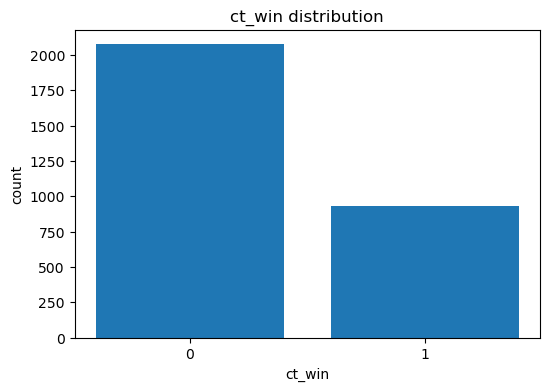

In [11]:
target_counts = snapshot_pd[TARGET_COL].value_counts().sort_index()
print(target_counts)
print(target_counts / len(snapshot_pd))

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("ct_win distribution")
plt.xlabel("ct_win")
plt.ylabel("count")
plt.show()

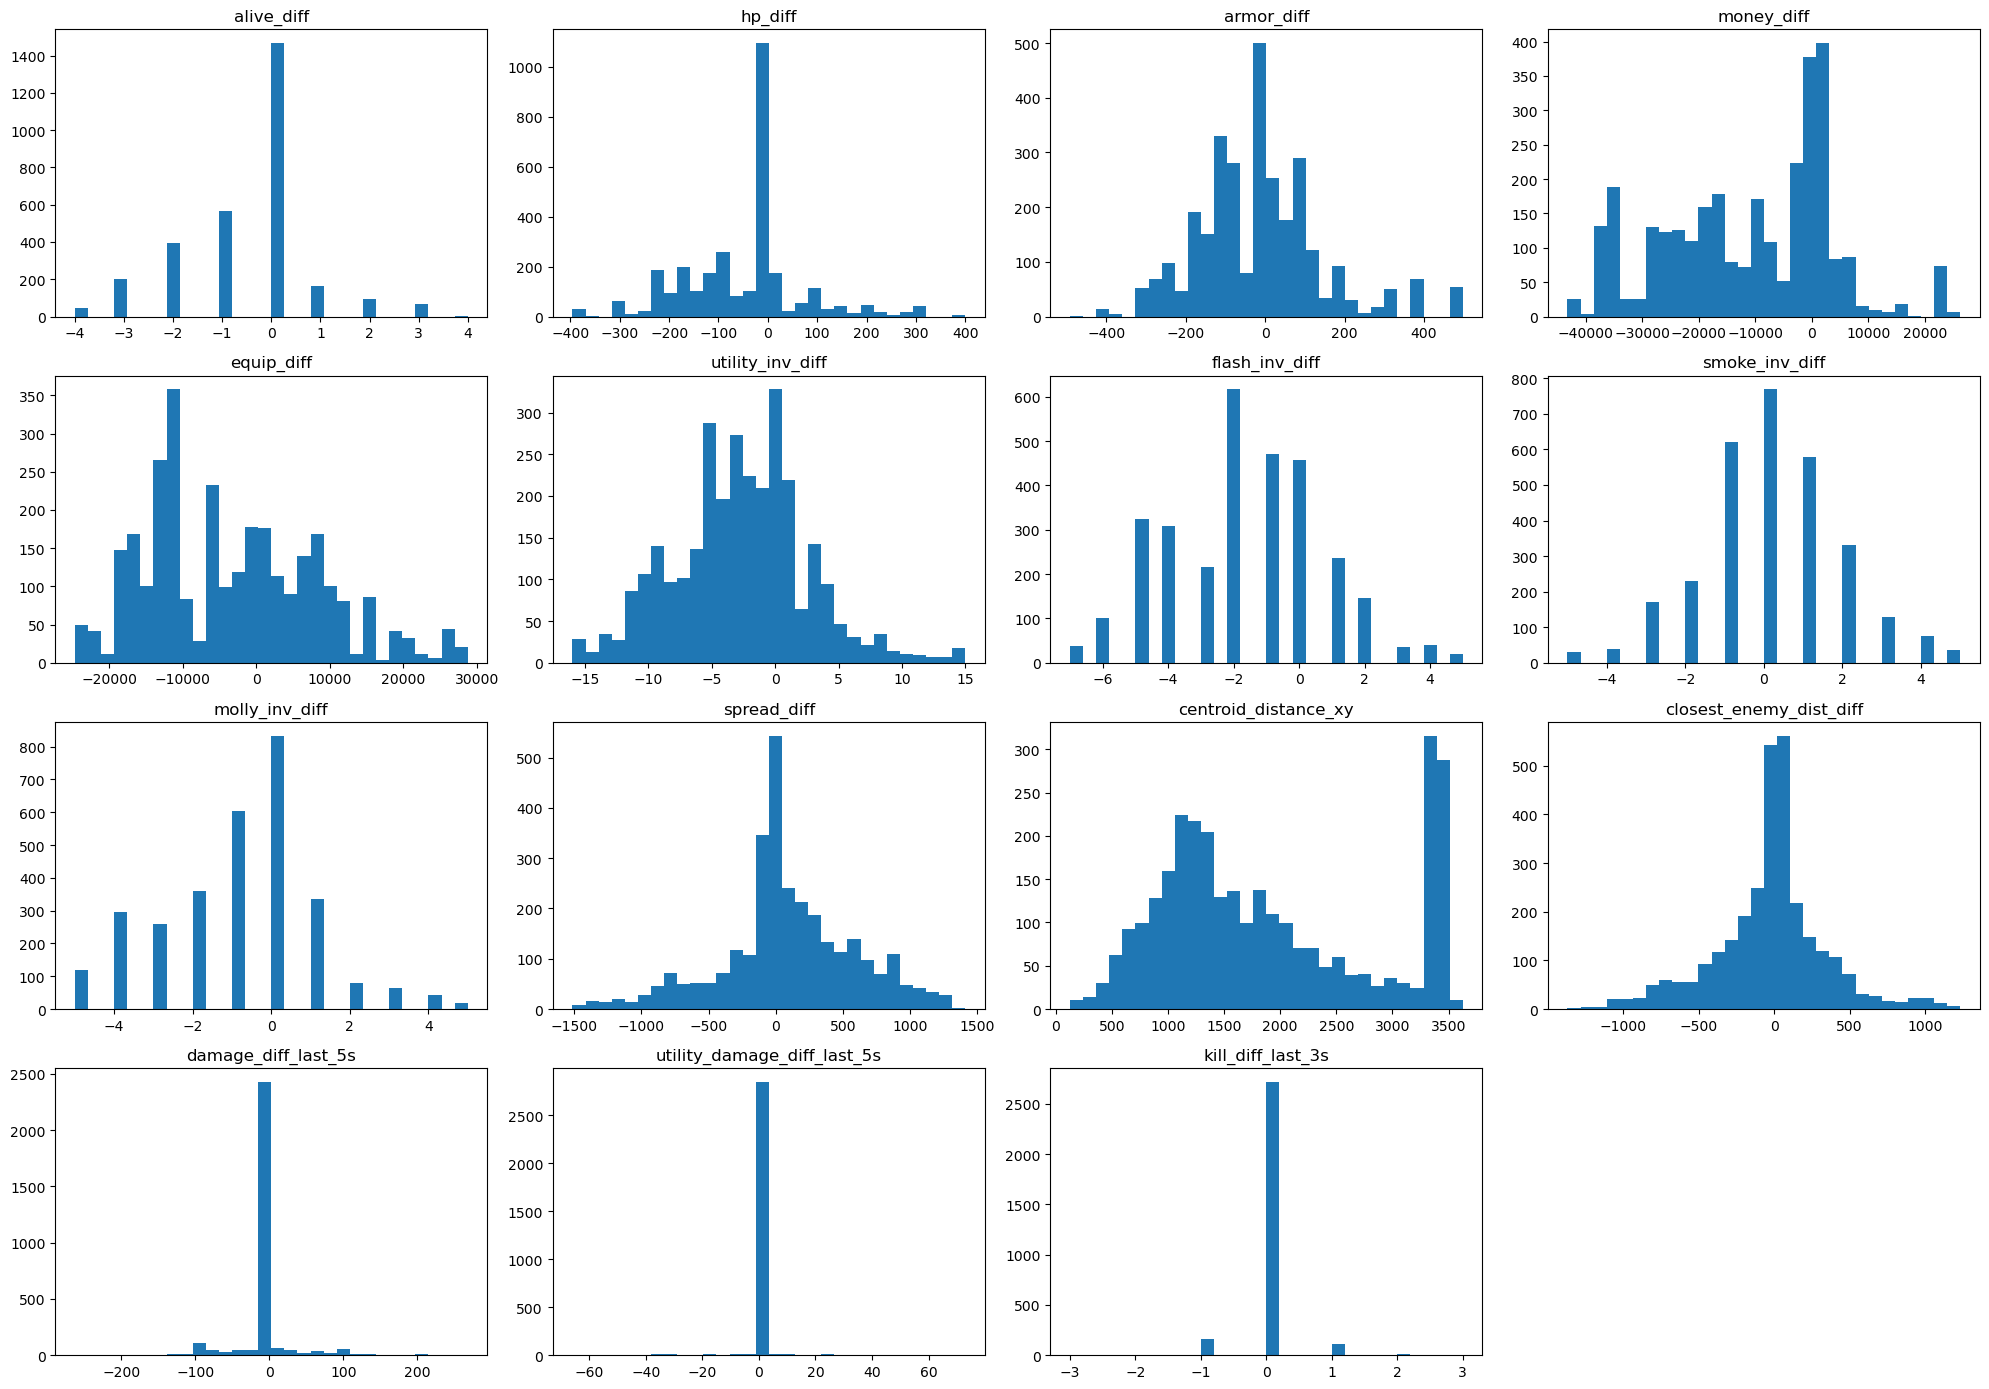

In [12]:
important_diff_cols = [
    "alive_diff",
    "hp_diff",
    "armor_diff",
    "money_diff",
    "equip_diff",
    "utility_inv_diff",
    "flash_inv_diff",
    "smoke_inv_diff",
    "molly_inv_diff",
    "spread_diff",
    "centroid_distance_xy",
    "closest_enemy_dist_diff",
    "damage_diff_last_5s",
    "utility_damage_diff_last_5s",
    "kill_diff_last_3s"
]

valid_diff_cols = [c for c in important_diff_cols if c in snapshot_pd.columns]

ncols = 4
nrows = math.ceil(len(valid_diff_cols) / ncols)

plt.figure(figsize=(5*ncols, 3.5*nrows))
for i, col in enumerate(valid_diff_cols, 1):
    plt.subplot(nrows, ncols, i)
    plt.hist(snapshot_pd[col].dropna(), bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

/var/folders/22/tcb8zb594nggygmq88qw5p8m0000gn/T/ipykernel_9075/872398606.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["ct_win=0", "ct_win=1"])
/var/folders/22/tcb8zb594nggygmq88qw5p8m0000gn/T/ipykernel_9075/872398606.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["ct_win=0", "ct_win=1"])
/var/folders/22/tcb8zb594nggygmq88qw5p8m0000gn/T/ipykernel_9075/872398606.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["ct_win=0", "ct_win=1"])
/var/folders/22/tcb8zb594nggygmq88qw5p8m0000gn/T/ipykernel_9075/872398606.py:23

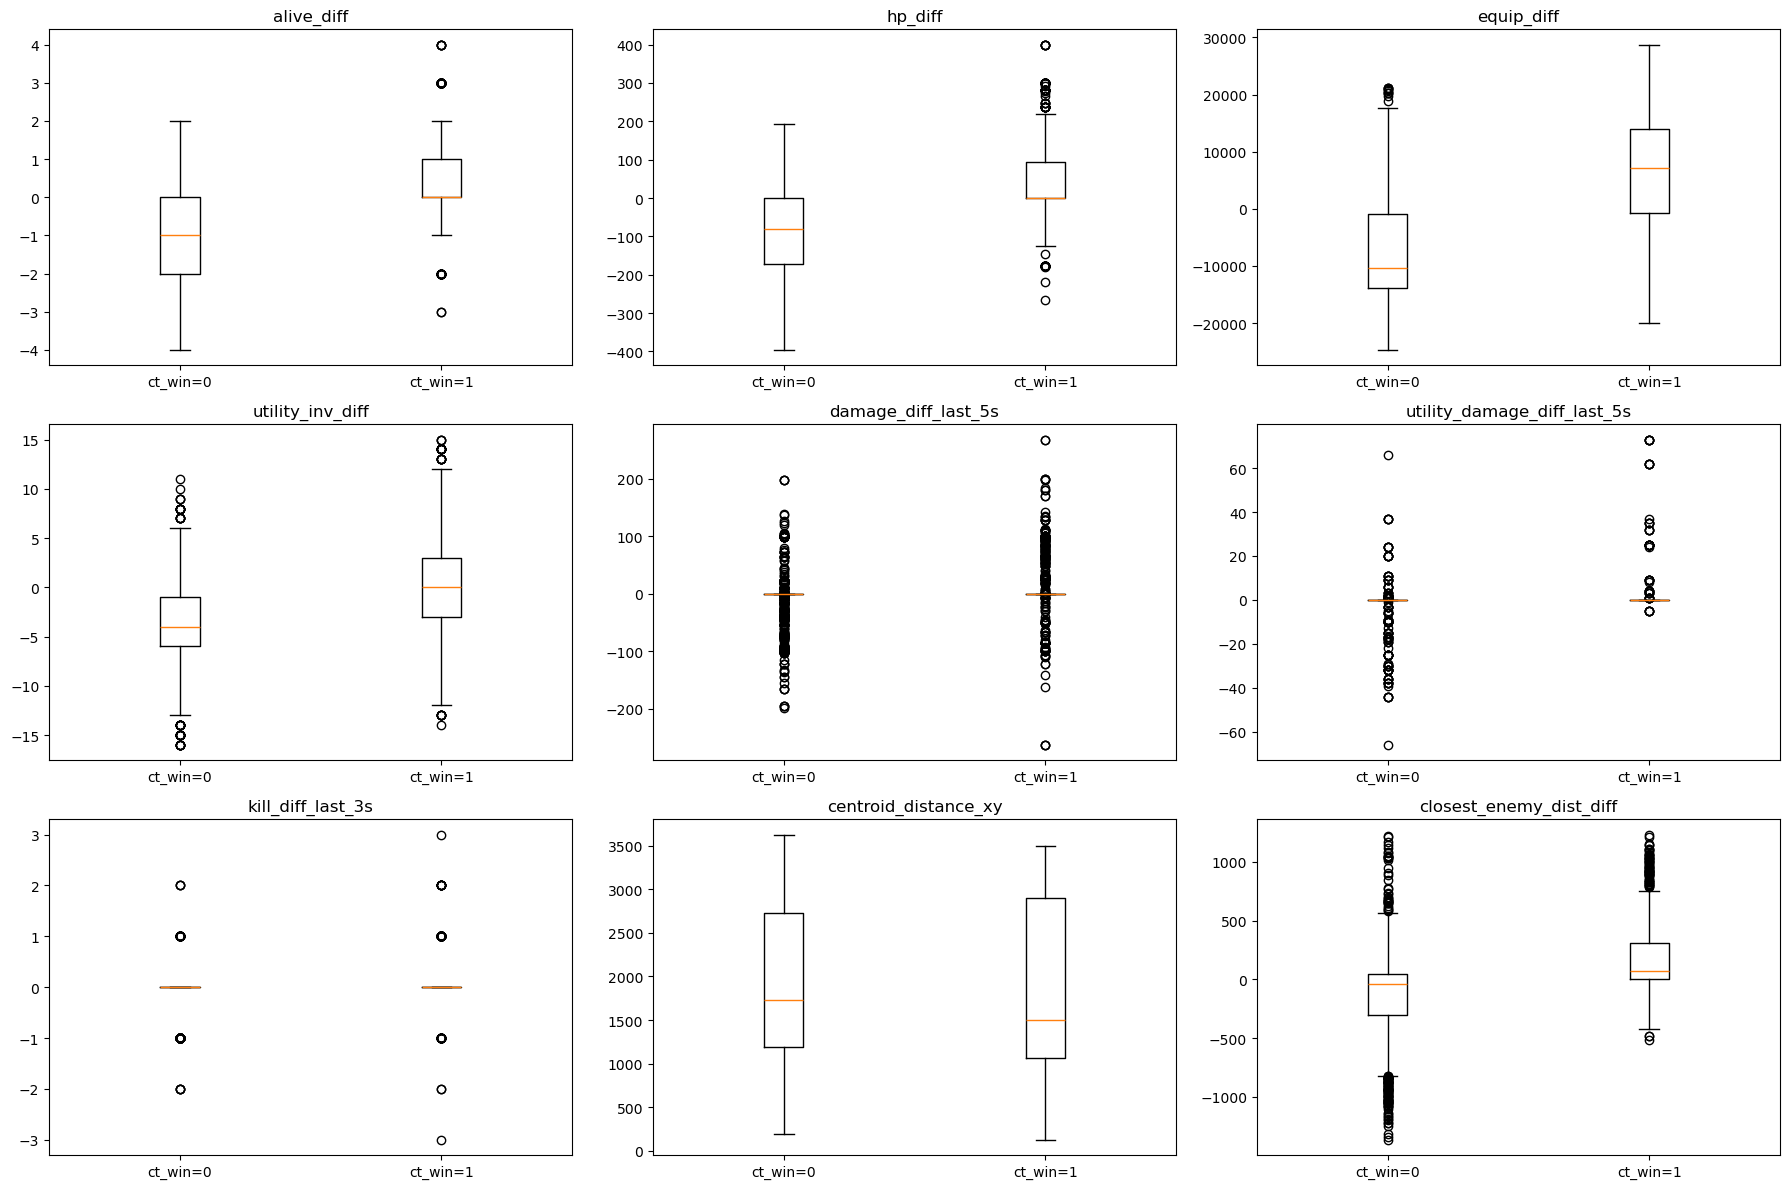

In [13]:
top_compare_cols = [
    "alive_diff",
    "hp_diff",
    "equip_diff",
    "utility_inv_diff",
    "damage_diff_last_5s",
    "utility_damage_diff_last_5s",
    "kill_diff_last_3s",
    "centroid_distance_xy",
    "closest_enemy_dist_diff"
]

valid_compare_cols = [c for c in top_compare_cols if c in snapshot_pd.columns]

ncols = 3
nrows = math.ceil(len(valid_compare_cols) / ncols)

plt.figure(figsize=(6*ncols, 4*nrows))
for i, col in enumerate(valid_compare_cols, 1):
    plt.subplot(nrows, ncols, i)
    g0 = snapshot_pd[snapshot_pd[TARGET_COL] == 0][col].dropna()
    g1 = snapshot_pd[snapshot_pd[TARGET_COL] == 1][col].dropna()
    plt.boxplot([g0, g1], labels=["ct_win=0", "ct_win=1"])
    plt.title(col)
plt.tight_layout()
plt.show()

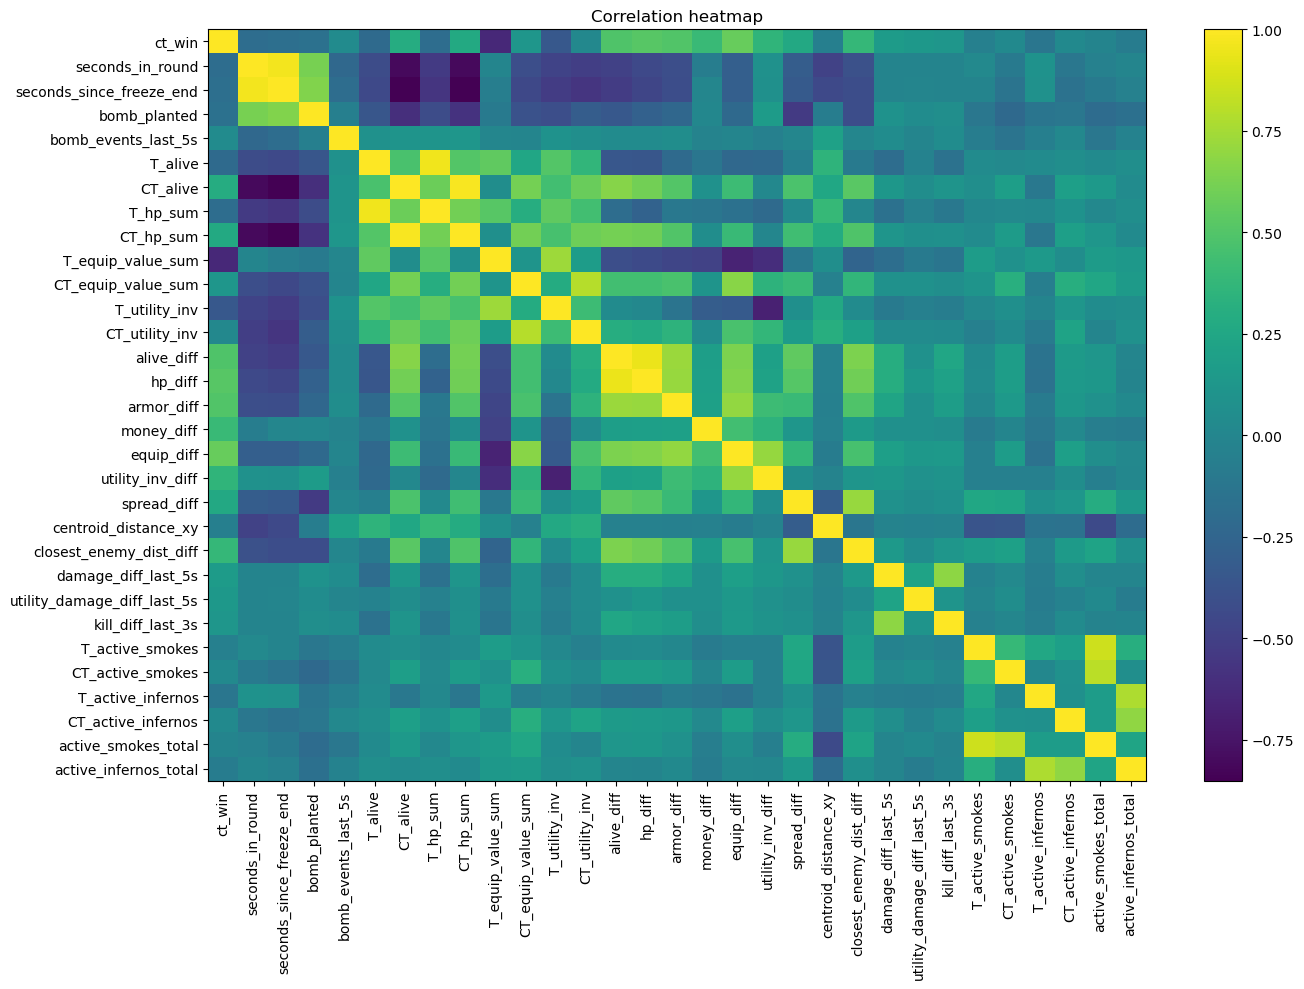

In [14]:
corr_cols = [
    "ct_win",
    "seconds_in_round",
    "seconds_since_freeze_end",
    "bomb_planted",
    "bomb_events_last_5s",
    "T_alive",
    "CT_alive",
    "T_hp_sum",
    "CT_hp_sum",
    "T_equip_value_sum",
    "CT_equip_value_sum",
    "T_utility_inv",
    "CT_utility_inv",
    "alive_diff",
    "hp_diff",
    "armor_diff",
    "money_diff",
    "equip_diff",
    "utility_inv_diff",
    "spread_diff",
    "centroid_distance_xy",
    "closest_enemy_dist_diff",
    "damage_diff_last_5s",
    "utility_damage_diff_last_5s",
    "kill_diff_last_3s",
    "T_active_smokes",
    "CT_active_smokes",
    "T_active_infernos",
    "CT_active_infernos",
    "active_smokes_total",
    "active_infernos_total"
]

corr_cols = [c for c in corr_cols if c in snapshot_pd.columns]
corr = snapshot_pd[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [15]:
target_corr_rows = []
for col in numeric_cols:
    if col == TARGET_COL:
        continue
    s = snapshot_pd[[col, TARGET_COL]].dropna()
    if s.shape[0] > 1 and s[col].nunique() > 1 and s[TARGET_COL].nunique() > 1:
        corr = s[col].corr(s[TARGET_COL])
        target_corr_rows.append({
            "feature": col,
            "corr_with_ct_win": corr,
            "abs_corr": abs(corr)
        })

target_corr_df = pd.DataFrame(target_corr_rows).sort_values("abs_corr", ascending=False)
print(target_corr_df.head(40))

                     feature  corr_with_ct_win  abs_corr
13         T_equip_value_sum         -0.636965  0.636965
15            T_helmet_count         -0.633590  0.633590
141     T_mollies_used_total         -0.619265  0.619265
167            T2_has_helmet         -0.610480  0.610480
139          T_he_used_total         -0.600699  0.600699
105               equip_diff          0.567483  0.567483
11       T_start_balance_sum         -0.541252  0.541252
282           CT4_has_helmet          0.528645  0.528645
216            T5_has_helmet         -0.525288  0.525288
102                  hp_diff          0.517873  0.517873
103               armor_diff          0.498044  0.498044
184            T3_has_helmet         -0.489279  0.489279
101               alive_diff          0.488553  0.488553
137     T_flashes_used_total         -0.475320  0.475320
14   T_round_start_equip_sum         -0.460765  0.460765
10               T_money_sum         -0.457936  0.457936
62           CT_helmet_count   

In [16]:
snapshot_phase_pd = snapshot_pd.copy()
snapshot_phase_pd["round_phase"] = np.where(
    snapshot_phase_pd["seconds_since_freeze_end"] < 20, "early",
    np.where(snapshot_phase_pd["seconds_since_freeze_end"] < 50, "mid", "late")
)

phase_cols = [
    "ct_win",
    "alive_diff",
    "hp_diff",
    "equip_diff",
    "utility_inv_diff",
    "damage_diff_last_5s",
    "kill_diff_last_3s",
    "active_smokes_total",
    "active_infernos_total"
]
phase_cols = [c for c in phase_cols if c in snapshot_phase_pd.columns]

phase_summary = snapshot_phase_pd.groupby("round_phase")[phase_cols].mean(numeric_only=True)
print(phase_summary)

               ct_win  alive_diff     hp_diff   equip_diff  utility_inv_diff  \
round_phase                                                                    
early        0.367387   -0.017682   -2.298625 -1064.341847         -2.974460   
late         0.234789   -1.227769 -106.724649 -6857.098284         -2.148986   
mid          0.365303    0.016925   -3.562764   -31.593794         -2.988717   

             damage_diff_last_5s  kill_diff_last_3s  active_smokes_total  \
round_phase                                                                
early                  -1.052063          -0.004912             0.594303   
late                   -4.028861          -0.033541             0.773011   
mid                     1.022567           0.014104             2.379408   

             active_infernos_total  
round_phase                         
early                     0.294695  
late                      0.231669  
mid                       0.262341  



 CT_A_site_active_smokes
CT_A_site_active_smokes
0    2600
1     378
2      31
Name: count, dtype: int64


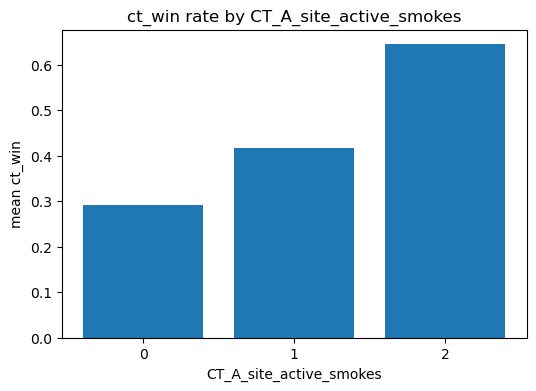


 CT_B_site_active_smokes
CT_B_site_active_smokes
0    2765
1     227
2      17
Name: count, dtype: int64


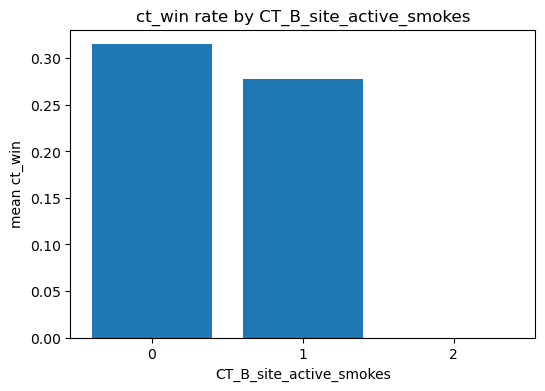


 T_A_site_active_smokes
T_A_site_active_smokes
0    2551
1     320
2      84
3      42
4      12
Name: count, dtype: int64


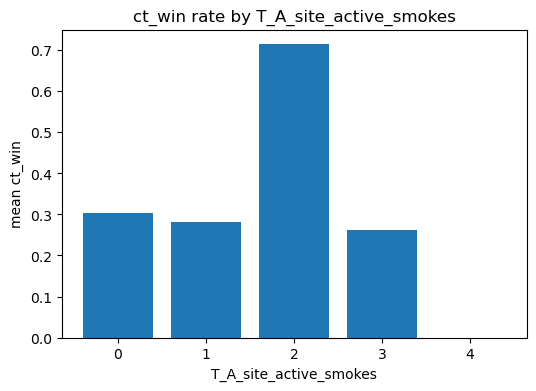


 T_B_site_active_smokes
T_B_site_active_smokes
0    2943
1      66
Name: count, dtype: int64


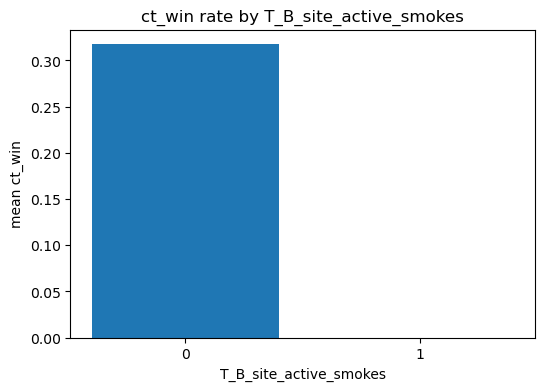


 CT_A_site_active_infernos
CT_A_site_active_infernos
0    2990
1      19
Name: count, dtype: int64


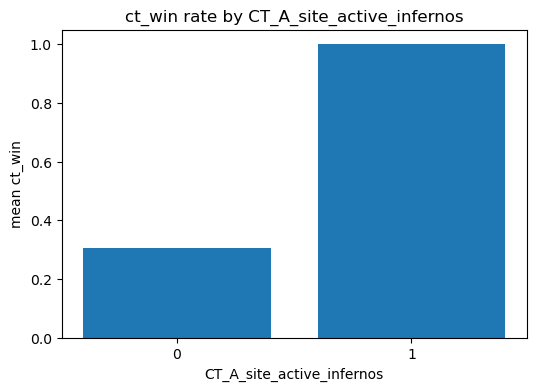


 CT_B_site_active_infernos
CT_B_site_active_infernos
0    2919
1      90
Name: count, dtype: int64


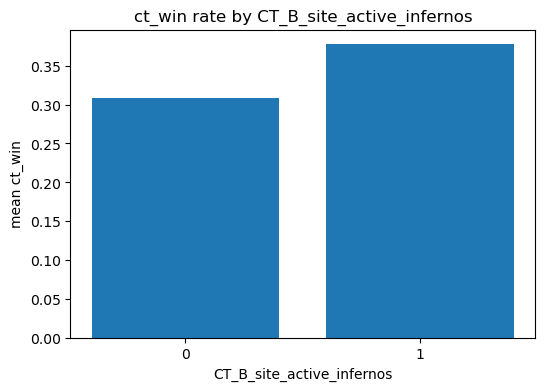


 T_A_site_active_infernos
T_A_site_active_infernos
0    2881
1     114
2      10
3       4
Name: count, dtype: int64


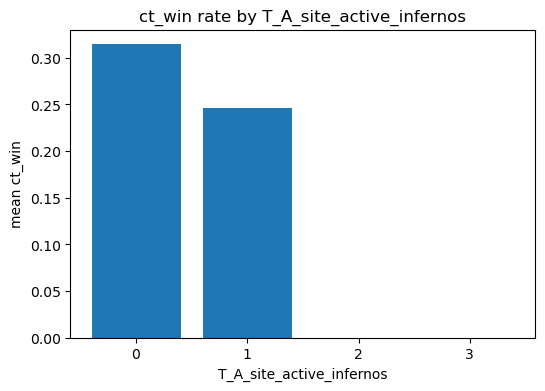


 T_B_site_active_infernos
T_B_site_active_infernos
0    2981
1      21
2       7
Name: count, dtype: int64


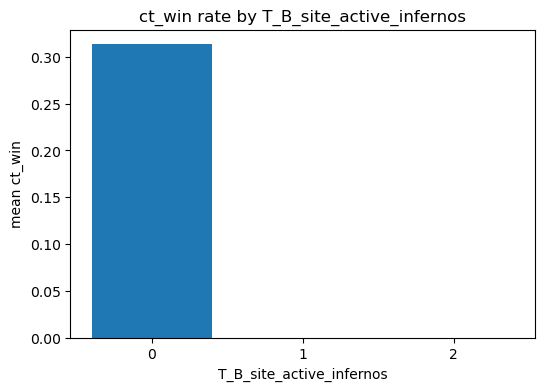

In [17]:
site_cols_to_check = [
    "CT_A_site_active_smokes",
    "CT_B_site_active_smokes",
    "T_A_site_active_smokes",
    "T_B_site_active_smokes",
    "CT_A_site_active_infernos",
    "CT_B_site_active_infernos",
    "T_A_site_active_infernos",
    "T_B_site_active_infernos",
]

site_cols_to_check = [c for c in site_cols_to_check if c in snapshot_pd.columns]

for col in site_cols_to_check:
    print("\n", col)
    print(snapshot_pd[col].value_counts().sort_index().head(20))

    grouped = snapshot_pd.groupby(col)[TARGET_COL].mean()
    plt.figure(figsize=(6, 4))
    plt.bar(grouped.index.astype(str), grouped.values)
    plt.title(f"ct_win rate by {col}")
    plt.xlabel(col)
    plt.ylabel("mean ct_win")
    plt.show()

In [18]:
player_numeric_cols = [
    c for c in snapshot_pd.columns
    if (
        c.startswith("T1_") or c.startswith("T2_") or c.startswith("T3_") or c.startswith("T4_") or c.startswith("T5_")
        or c.startswith("CT1_") or c.startswith("CT2_") or c.startswith("CT3_") or c.startswith("CT4_") or c.startswith("CT5_")
    )
    and snapshot_pd[c].dtype != "object"
    and not c.endswith("_steamid")
]

print("player numeric cols:", len(player_numeric_cols))
print(player_numeric_cols[:50])

player numeric cols: 180
['T1_alive', 'T1_hp', 'T1_armor', 'T1_has_helmet', 'T1_has_defuser', 'T1_is_scoped', 'T1_is_walking', 'T1_duck_amount', 'T1_flash_duration', 'T1_shots_fired', 'T1_X', 'T1_Y', 'T1_smoke', 'T1_flash', 'T1_he', 'T1_molly', 'T1_utility_total', 'T1_has_bomb', 'T2_alive', 'T2_hp', 'T2_armor', 'T2_has_helmet', 'T2_has_defuser', 'T2_is_scoped', 'T2_is_walking', 'T2_duck_amount', 'T2_flash_duration', 'T2_shots_fired', 'T2_X', 'T2_Y', 'T2_smoke', 'T2_flash', 'T2_he', 'T2_molly', 'T2_utility_total', 'T2_has_bomb', 'T3_alive', 'T3_hp', 'T3_armor', 'T3_has_helmet', 'T3_has_defuser', 'T3_is_scoped', 'T3_is_walking', 'T3_duck_amount', 'T3_flash_duration', 'T3_shots_fired', 'T3_X', 'T3_Y', 'T3_smoke', 'T3_flash']


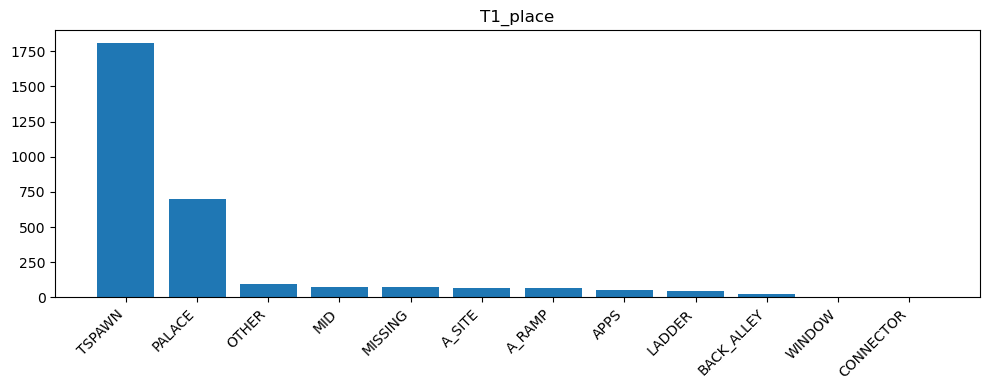

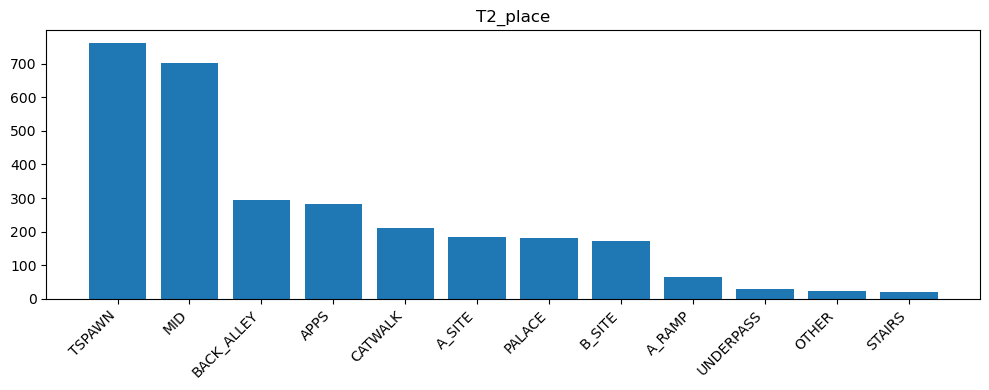

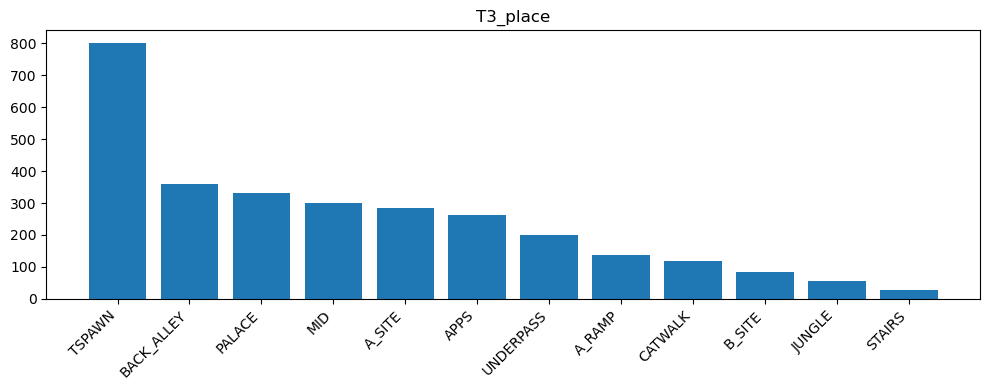

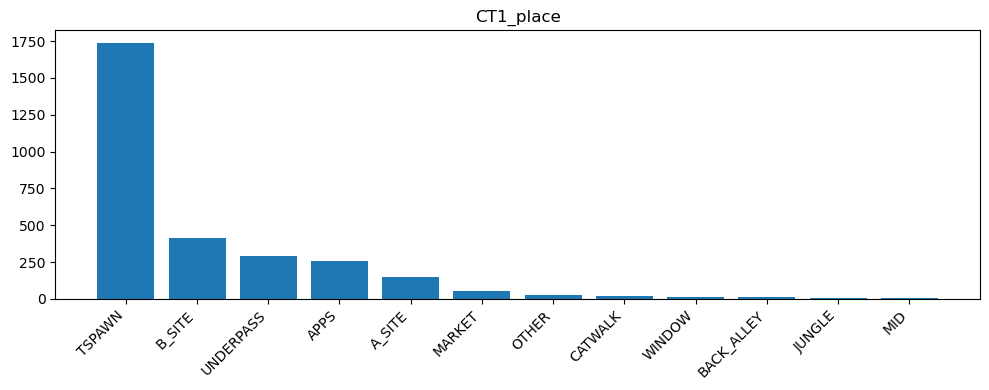

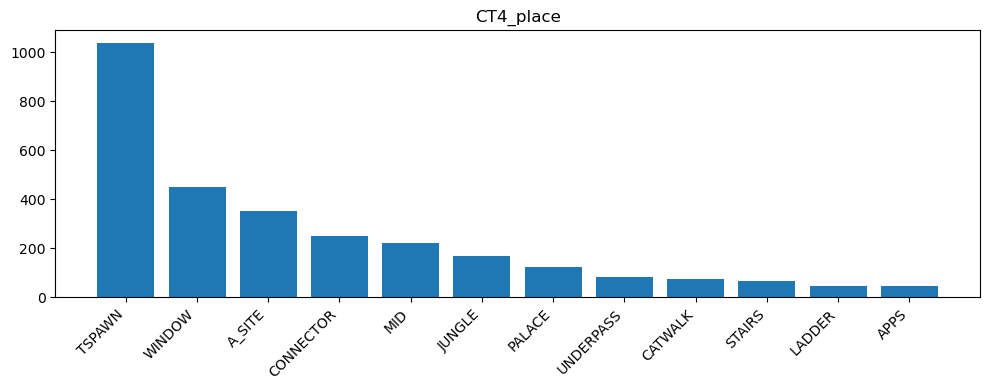

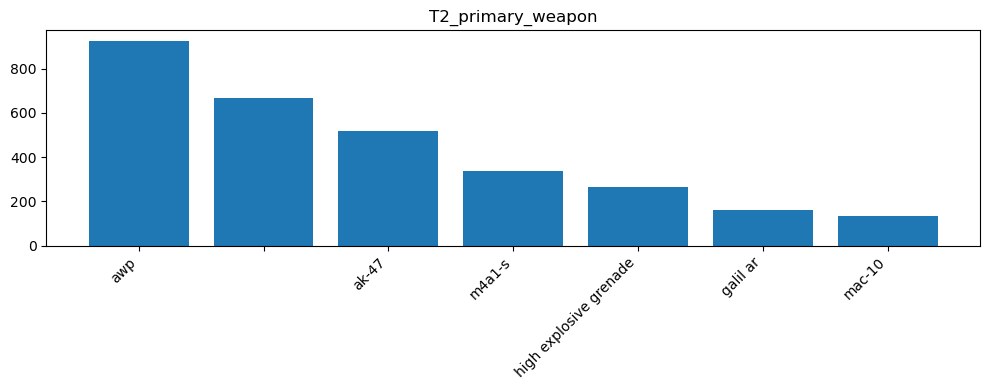

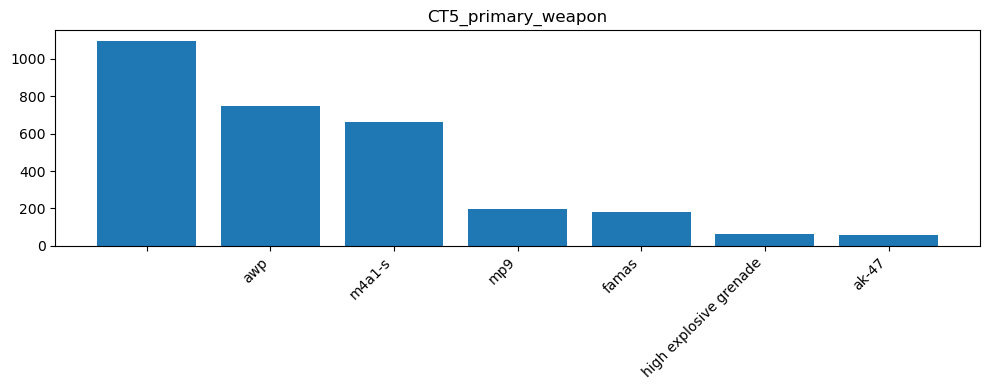

In [19]:
def plot_top_categories(df, col, top_n=12):
    vc = df[col].fillna("MISSING").astype(str).value_counts().head(top_n)

    plt.figure(figsize=(10, 4))
    plt.bar(vc.index, vc.values)
    plt.title(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in ["T1_place", "T2_place", "T3_place", "CT1_place", "CT4_place", "T2_primary_weapon", "CT5_primary_weapon"]:
    if col in snapshot_pd.columns:
        plot_top_categories(snapshot_pd, col)

In [20]:
snapshot_pd["T_alive_check"] = snapshot_pd[[c for c in snapshot_pd.columns if c.startswith("T") and c.endswith("_alive") and c != "T_alive"]].sum(axis=1)
snapshot_pd["CT_alive_check"] = snapshot_pd[[c for c in snapshot_pd.columns if c.startswith("CT") and c.endswith("_alive") and c != "CT_alive"]].sum(axis=1)

print("T_alive mismatches:", (snapshot_pd["T_alive"] != snapshot_pd["T_alive_check"]).sum())
print("CT_alive mismatches:", (snapshot_pd["CT_alive"] != snapshot_pd["CT_alive_check"]).sum())

if "active_smokes_total" in snapshot_pd.columns:
    print("active_smokes_total mismatches:", (
        snapshot_pd["active_smokes_total"] != (snapshot_pd["T_active_smokes"] + snapshot_pd["CT_active_smokes"])
    ).sum())

if "active_infernos_total" in snapshot_pd.columns:
    print("active_infernos_total mismatches:", (
        snapshot_pd["active_infernos_total"] != (snapshot_pd["T_active_infernos"] + snapshot_pd["CT_active_infernos"])
    ).sum())

T_alive mismatches: 1580
CT_alive mismatches: 1259
active_smokes_total mismatches: 0
active_infernos_total mismatches: 0


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

snapshot_pd = snapshot_df.to_pandas().copy()
TARGET_COL = "ct_win"

print(snapshot_pd.shape)
print("Target exists:", TARGET_COL in snapshot_pd.columns)

(3009, 413)
Target exists: True


/var/folders/22/tcb8zb594nggygmq88qw5p8m0000gn/T/ipykernel_9075/3435224718.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = temp.pivot_table(


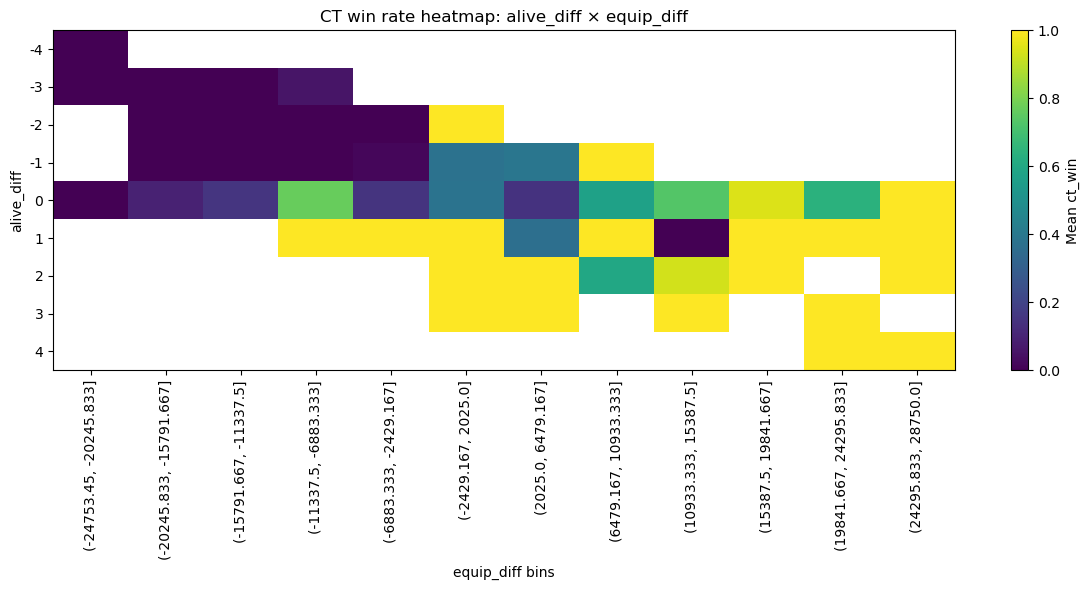

In [22]:
# 1. alive_diff × equip_diff -> ct_win heatmap

if all(col in snapshot_pd.columns for col in ["alive_diff", "equip_diff", TARGET_COL]):
    temp = snapshot_pd[["alive_diff", "equip_diff", TARGET_COL]].dropna().copy()

    temp["alive_bin"] = temp["alive_diff"].astype(int)

    equip_min = temp["equip_diff"].min()
    equip_max = temp["equip_diff"].max()

    # 12 bin az equip_diff-re
    temp["equip_bin"] = pd.cut(temp["equip_diff"], bins=12)

    pivot = temp.pivot_table(
        index="alive_bin",
        columns="equip_bin",
        values=TARGET_COL,
        aggfunc="mean"
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label="Mean ct_win")
    plt.title("CT win rate heatmap: alive_diff × equip_diff")
    plt.xlabel("equip_diff bins")
    plt.ylabel("alive_diff")
    plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=90)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.tight_layout()
    plt.show()
else:
    print("Missing required columns for plot 1")

                     feature      corr  abs_corr
13         T_equip_value_sum -0.636965  0.636965
15            T_helmet_count -0.633590  0.633590
141     T_mollies_used_total -0.619265  0.619265
167            T2_has_helmet -0.610480  0.610480
139          T_he_used_total -0.600699  0.600699
105               equip_diff  0.567483  0.567483
11       T_start_balance_sum -0.541252  0.541252
282           CT4_has_helmet  0.528645  0.528645
216            T5_has_helmet -0.525288  0.525288
102                  hp_diff  0.517873  0.517873
103               armor_diff  0.498044  0.498044
184            T3_has_helmet -0.489279  0.489279
101               alive_diff  0.488553  0.488553
137     T_flashes_used_total -0.475320  0.475320
14   T_round_start_equip_sum -0.460765  0.460765
10               T_money_sum -0.457936  0.457936
62           CT_helmet_count  0.442010  0.442010
200            T4_has_helmet -0.425486  0.425486
27               T_flash_inv -0.419079  0.419079
107           flash_

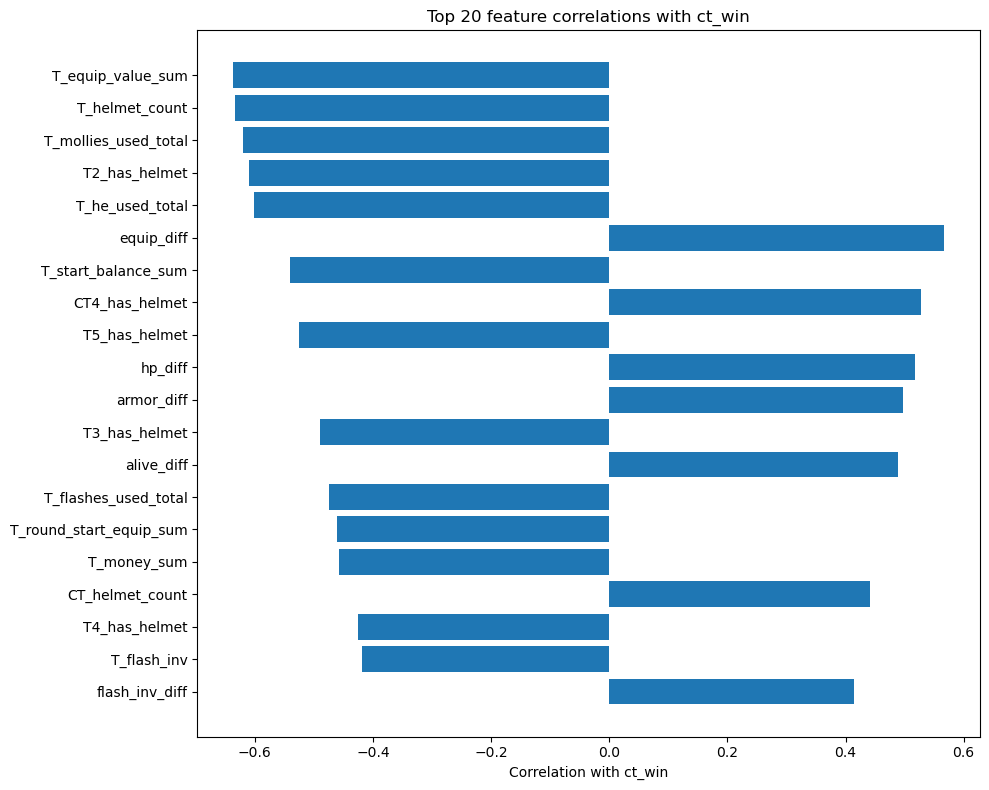

In [23]:
# 2. top feature correlation with ct_win

if TARGET_COL in snapshot_pd.columns:
    numeric_cols = snapshot_pd.select_dtypes(include=[np.number]).columns.tolist()

    corr_rows = []
    for col in numeric_cols:
        if col == TARGET_COL:
            continue
        s = snapshot_pd[[col, TARGET_COL]].dropna()
        if s.shape[0] > 1 and s[col].nunique() > 1 and s[TARGET_COL].nunique() > 1:
            corr = s[col].corr(s[TARGET_COL])
            corr_rows.append({
                "feature": col,
                "corr": corr,
                "abs_corr": abs(corr)
            })

    corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)
    top_corr_df = corr_df.head(20)

    print(top_corr_df)

    plt.figure(figsize=(10, 8))
    plt.barh(top_corr_df["feature"][::-1], top_corr_df["corr"][::-1])
    plt.title("Top 20 feature correlations with ct_win")
    plt.xlabel("Correlation with ct_win")
    plt.tight_layout()
    plt.show()
else:
    print("Target column missing")

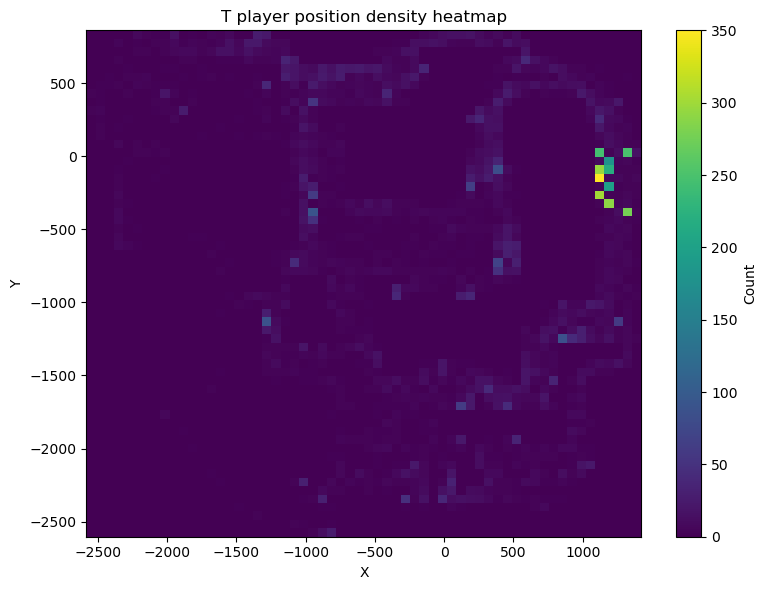

In [25]:
# 4. X-Y density heatmap for T side

t_x_cols = [f"T{i}_X" for i in range(1, 6) if f"T{i}_X" in snapshot_pd.columns]
t_y_cols = [f"T{i}_Y" for i in range(1, 6) if f"T{i}_Y" in snapshot_pd.columns]
t_alive_cols = [f"T{i}_alive" for i in range(1, 6) if f"T{i}_alive" in snapshot_pd.columns]

if len(t_x_cols) == 5 and len(t_y_cols) == 5 and len(t_alive_cols) == 5:
    xs = []
    ys = []

    for i in range(1, 6):
        x_col = f"T{i}_X"
        y_col = f"T{i}_Y"
        a_col = f"T{i}_alive"

        sub = snapshot_pd[[x_col, y_col, a_col]].dropna()
        sub = sub[sub[a_col] == 1]

        xs.extend(sub[x_col].tolist())
        ys.extend(sub[y_col].tolist())

    plt.figure(figsize=(8, 6))
    plt.hist2d(xs, ys, bins=60)
    plt.colorbar(label="Count")
    plt.title("T player position density heatmap")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()
else:
    print("Missing T position/alive columns for plot 4")

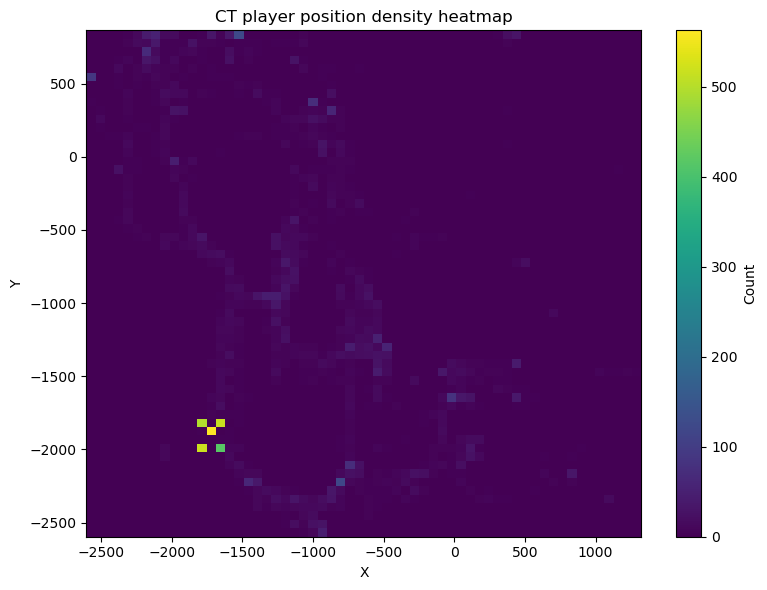

In [26]:
# 5. X-Y density heatmap for CT side

ct_x_cols = [f"CT{i}_X" for i in range(1, 6) if f"CT{i}_X" in snapshot_pd.columns]
ct_y_cols = [f"CT{i}_Y" for i in range(1, 6) if f"CT{i}_Y" in snapshot_pd.columns]
ct_alive_cols = [f"CT{i}_alive" for i in range(1, 6) if f"CT{i}_alive" in snapshot_pd.columns]

if len(ct_x_cols) == 5 and len(ct_y_cols) == 5 and len(ct_alive_cols) == 5:
    xs = []
    ys = []

    for i in range(1, 6):
        x_col = f"CT{i}_X"
        y_col = f"CT{i}_Y"
        a_col = f"CT{i}_alive"

        sub = snapshot_pd[[x_col, y_col, a_col]].dropna()
        sub = sub[sub[a_col] == 1]

        xs.extend(sub[x_col].tolist())
        ys.extend(sub[y_col].tolist())

    plt.figure(figsize=(8, 6))
    plt.hist2d(xs, ys, bins=60)
    plt.colorbar(label="Count")
    plt.title("CT player position density heatmap")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()
else:
    print("Missing CT position/alive columns for plot 5")

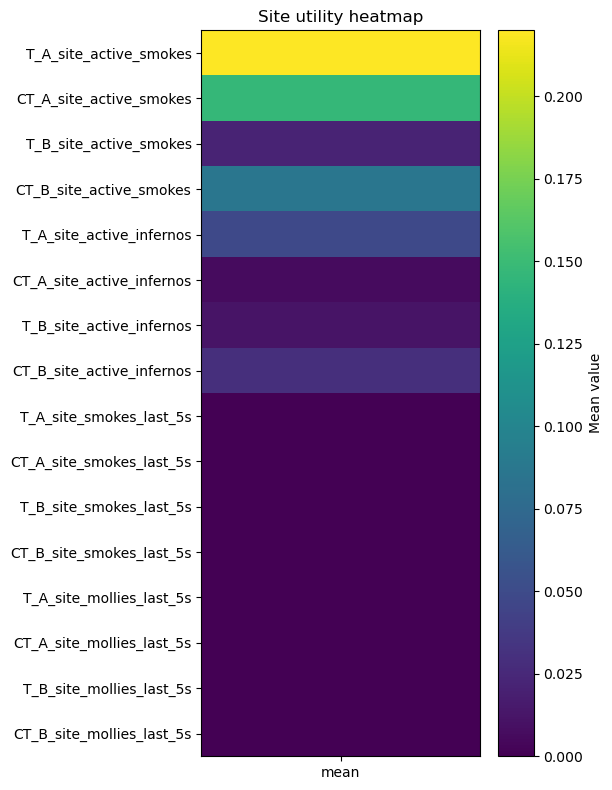

                           mean_value
T_A_site_active_smokes       0.220007
CT_A_site_active_smokes      0.146228
CT_B_site_active_smokes      0.086740
T_A_site_active_infernos     0.048521
CT_B_site_active_infernos    0.029910
T_B_site_active_smokes       0.021934
T_B_site_active_infernos     0.011632
CT_A_site_active_infernos    0.006314
T_A_site_smokes_last_5s      0.000000
CT_A_site_smokes_last_5s     0.000000
T_B_site_smokes_last_5s      0.000000
CT_B_site_smokes_last_5s     0.000000
T_A_site_mollies_last_5s     0.000000
CT_A_site_mollies_last_5s    0.000000
T_B_site_mollies_last_5s     0.000000
CT_B_site_mollies_last_5s    0.000000


In [27]:
# 6. site utility heatmap

site_utility_cols = [
    "T_A_site_active_smokes",
    "CT_A_site_active_smokes",
    "T_B_site_active_smokes",
    "CT_B_site_active_smokes",
    "T_A_site_active_infernos",
    "CT_A_site_active_infernos",
    "T_B_site_active_infernos",
    "CT_B_site_active_infernos",
    "T_A_site_smokes_last_5s",
    "CT_A_site_smokes_last_5s",
    "T_B_site_smokes_last_5s",
    "CT_B_site_smokes_last_5s",
    "T_A_site_mollies_last_5s",
    "CT_A_site_mollies_last_5s",
    "T_B_site_mollies_last_5s",
    "CT_B_site_mollies_last_5s",
]

site_utility_cols = [c for c in site_utility_cols if c in snapshot_pd.columns]

if len(site_utility_cols) > 0:
    site_summary = snapshot_pd[site_utility_cols].mean().to_frame(name="mean_value")

    plt.figure(figsize=(6, 8))
    plt.imshow(site_summary, aspect="auto")
    plt.colorbar(label="Mean value")
    plt.title("Site utility heatmap")
    plt.xticks([0], ["mean"])
    plt.yticks(range(len(site_summary.index)), site_summary.index)
    plt.tight_layout()
    plt.show()

    print(site_summary.sort_values("mean_value", ascending=False))
else:
    print("No site utility columns found")

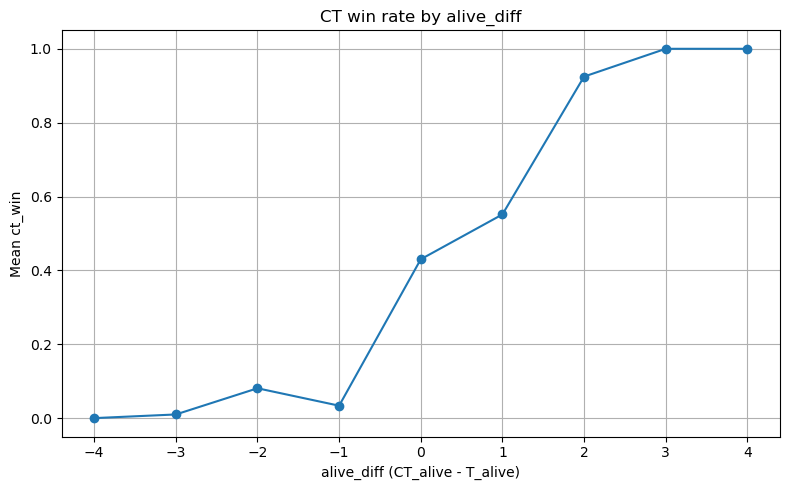

alive_diff
-4    0.000000
-3    0.009901
-2    0.080808
-1    0.033628
 0    0.430130
 1    0.551515
 2    0.924731
 3    1.000000
 4    1.000000
Name: ct_win, dtype: float64


In [28]:
# 7. alive_diff -> ct_win curve

if all(col in snapshot_pd.columns for col in ["alive_diff", TARGET_COL]):
    grouped = snapshot_pd.groupby("alive_diff")[TARGET_COL].mean().sort_index()

    plt.figure(figsize=(8, 5))
    plt.plot(grouped.index, grouped.values, marker="o")
    plt.title("CT win rate by alive_diff")
    plt.xlabel("alive_diff (CT_alive - T_alive)")
    plt.ylabel("Mean ct_win")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(grouped)
else:
    print("Missing required columns for plot 7")

/var/folders/22/tcb8zb594nggygmq88qw5p8m0000gn/T/ipykernel_9075/3232351715.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby("equip_bin")[TARGET_COL].mean()
/var/folders/22/tcb8zb594nggygmq88qw5p8m0000gn/T/ipykernel_9075/3232351715.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp.groupby("equip_bin")[TARGET_COL].count()


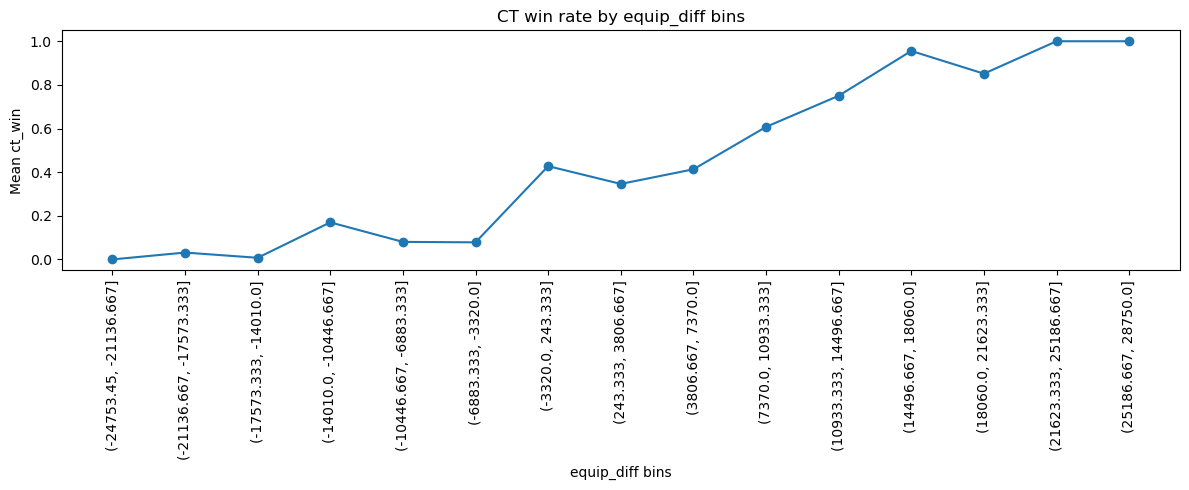

                   equip_bin  mean_ct_win  count
0    (-24753.45, -21136.667]     0.000000     90
1   (-21136.667, -17573.333]     0.031447    159
2     (-17573.333, -14010.0]     0.007463    268
3     (-14010.0, -10446.667]     0.169872    624
4    (-10446.667, -6883.333]     0.080357    112
5       (-6883.333, -3320.0]     0.078313    332
6         (-3320.0, 243.333]     0.427609    297
7        (243.333, 3806.667]     0.346021    289
8         (3806.667, 7370.0]     0.413043    230
9        (7370.0, 10933.333]     0.607407    270
10    (10933.333, 14496.667]     0.750000     92
11      (14496.667, 18060.0]     0.955556     90
12      (18060.0, 21623.333]     0.851351     74
13    (21623.333, 25186.667]     1.000000     18
14      (25186.667, 28750.0]     1.000000     64


In [29]:
# 8. equip_diff -> ct_win binned curve

if all(col in snapshot_pd.columns for col in ["equip_diff", TARGET_COL]):
    temp = snapshot_pd[["equip_diff", TARGET_COL]].dropna().copy()
    temp["equip_bin"] = pd.cut(temp["equip_diff"], bins=15)

    grouped = temp.groupby("equip_bin")[TARGET_COL].mean()
    counts = temp.groupby("equip_bin")[TARGET_COL].count()

    plt.figure(figsize=(12, 5))
    plt.plot(range(len(grouped)), grouped.values, marker="o")
    plt.title("CT win rate by equip_diff bins")
    plt.xlabel("equip_diff bins")
    plt.ylabel("Mean ct_win")
    plt.xticks(range(len(grouped)), [str(i) for i in grouped.index], rotation=90)
    plt.tight_layout()
    plt.show()

    print(pd.DataFrame({
        "equip_bin": grouped.index.astype(str),
        "mean_ct_win": grouped.values,
        "count": counts.values
    }))
else:
    print("Missing required columns for plot 8")

In [31]:
print(dem.grenades.columns)
print(dem.smokes.columns)
print(dem.infernos.columns)

['thrower_steamid', 'thrower', 'grenade_type', 'tick', 'X', 'Y', 'Z', 'entity_id', 'round_num']
['entity_id', 'start_tick', 'end_tick', 'thrower_X', 'thrower_Y', 'thrower_Z', 'thrower_health', 'thrower_place', 'thrower_name', 'thrower_steamid', 'thrower_side', 'X', 'Y', 'Z', 'round_num']
['entity_id', 'start_tick', 'end_tick', 'thrower_X', 'thrower_Y', 'thrower_Z', 'thrower_health', 'thrower_place', 'thrower_name', 'thrower_steamid', 'thrower_side', 'X', 'Y', 'Z', 'round_num']


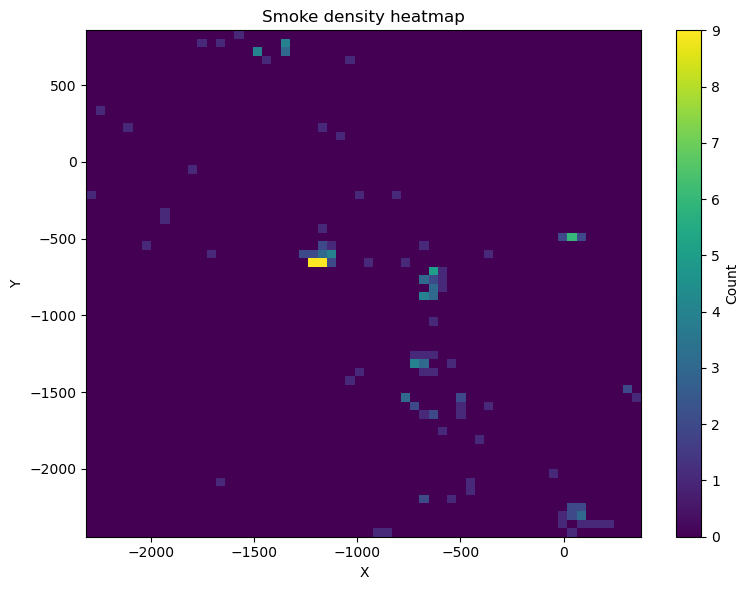

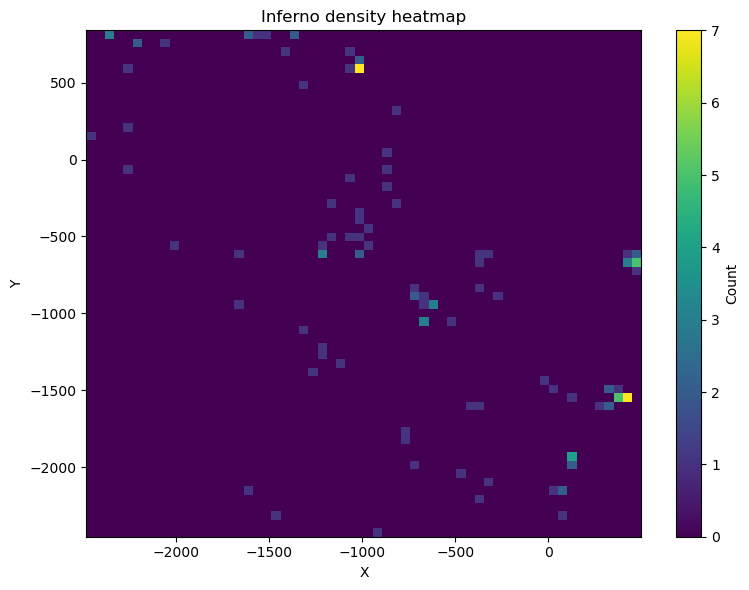

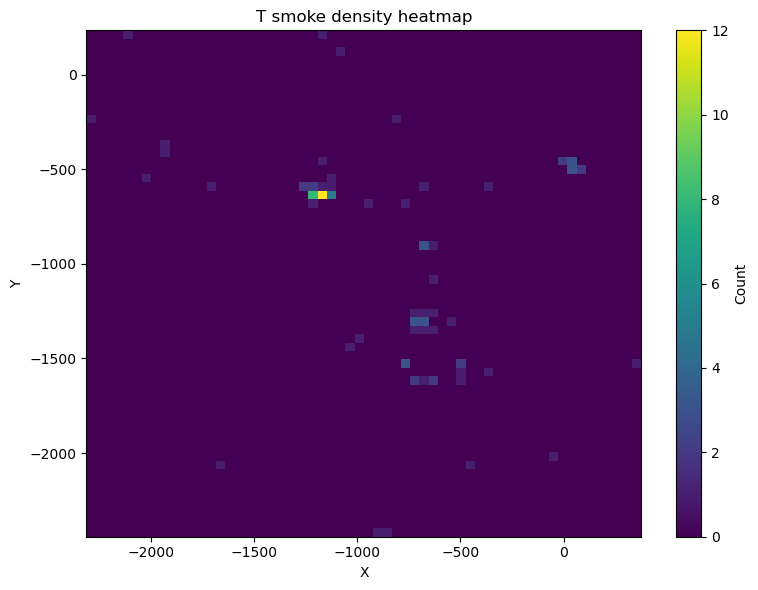

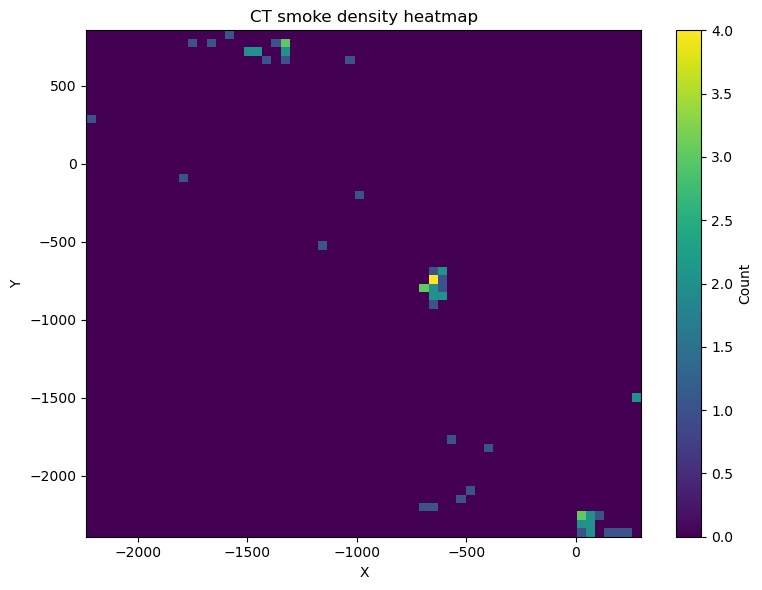

Nincs használható koordináta ehhez: Utility density: CFlashbang


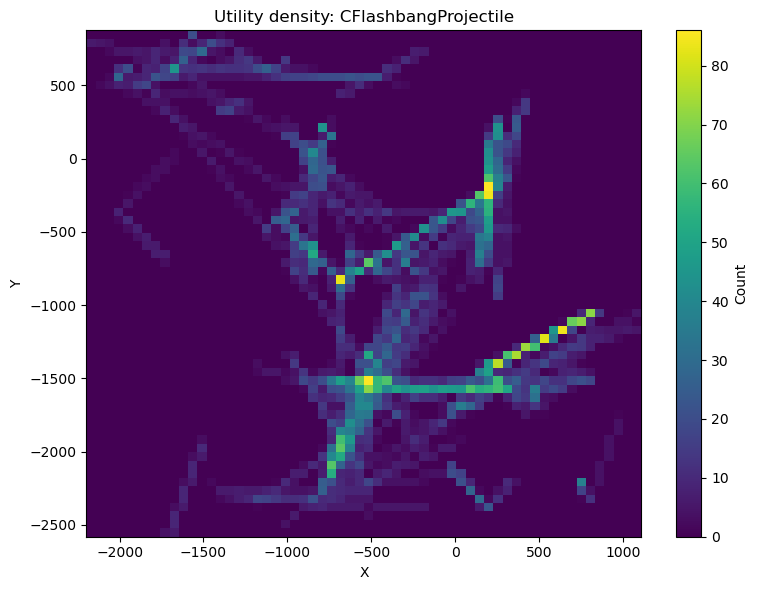

Nincs használható koordináta ehhez: Utility density: CHEGrenade


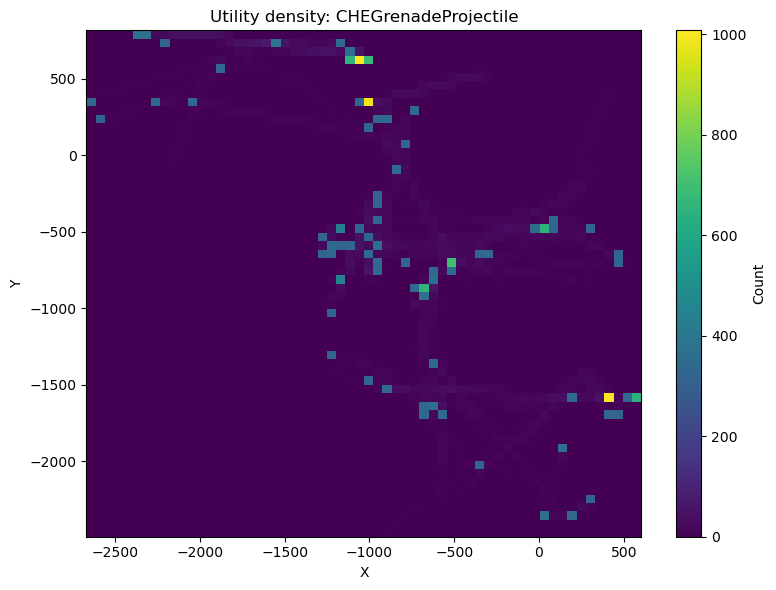

Nincs használható koordináta ehhez: Utility density: CIncendiaryGrenade
Nincs használható koordináta ehhez: Utility density: CMolotovGrenade


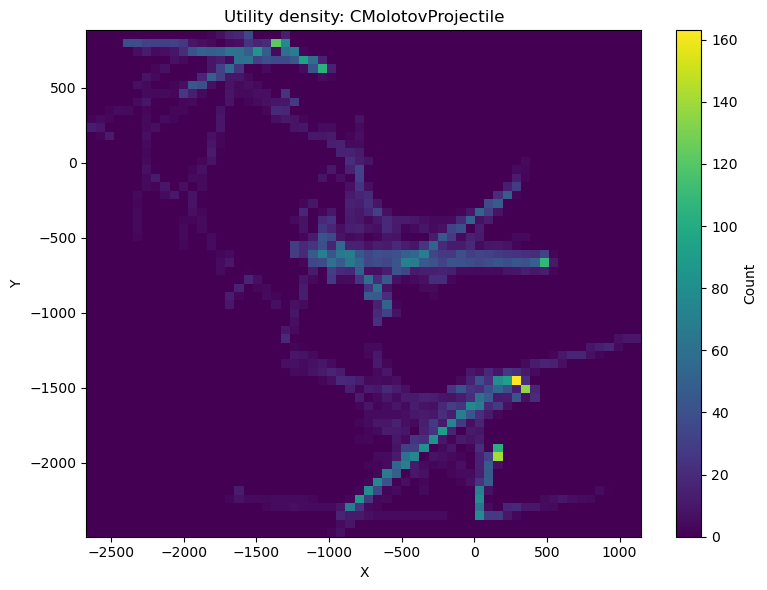

Nincs használható koordináta ehhez: Utility density: CSmokeGrenade


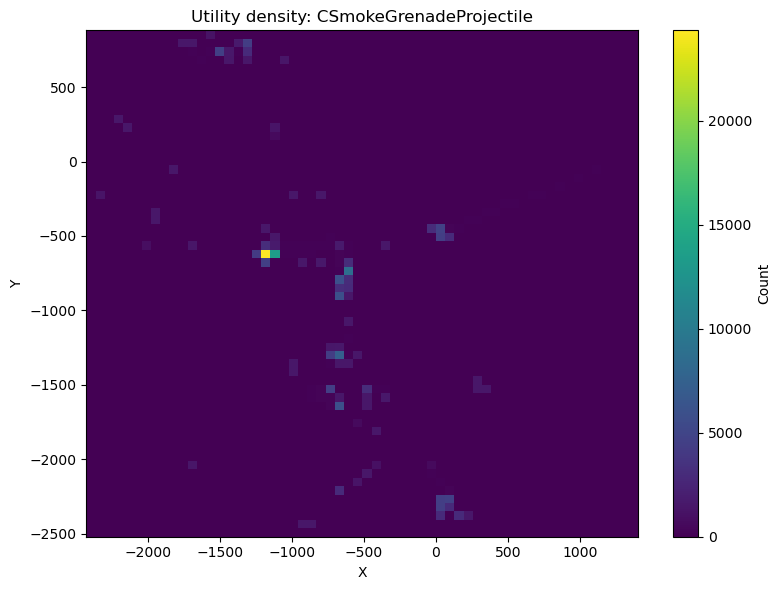

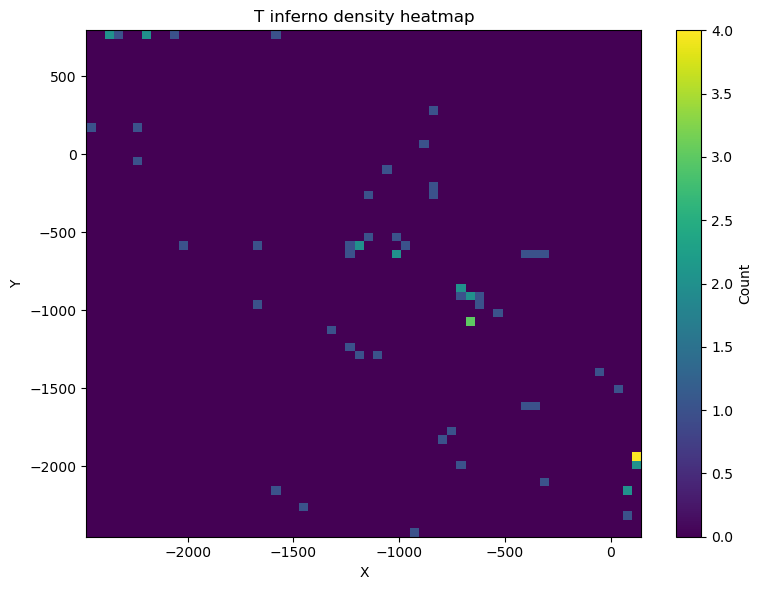

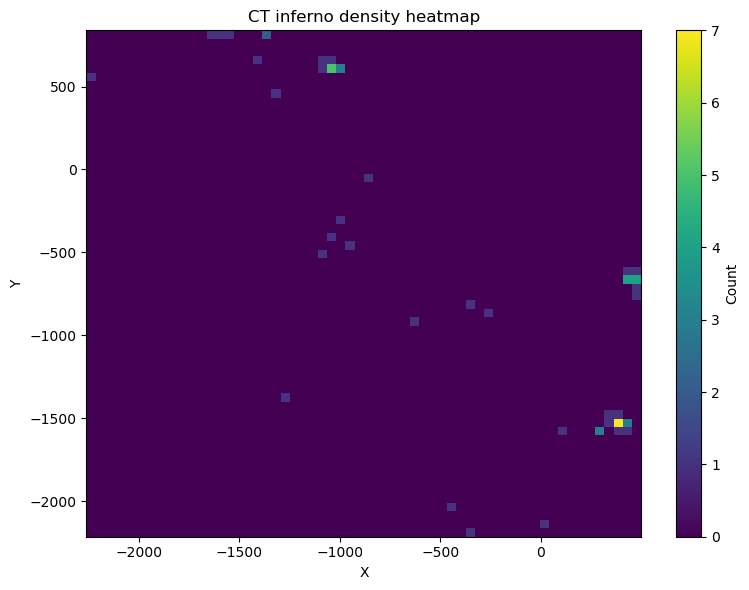

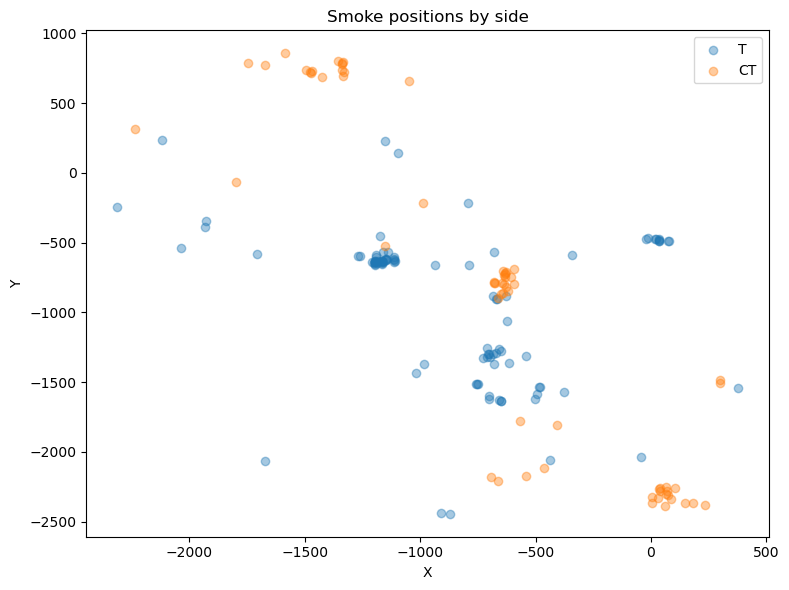

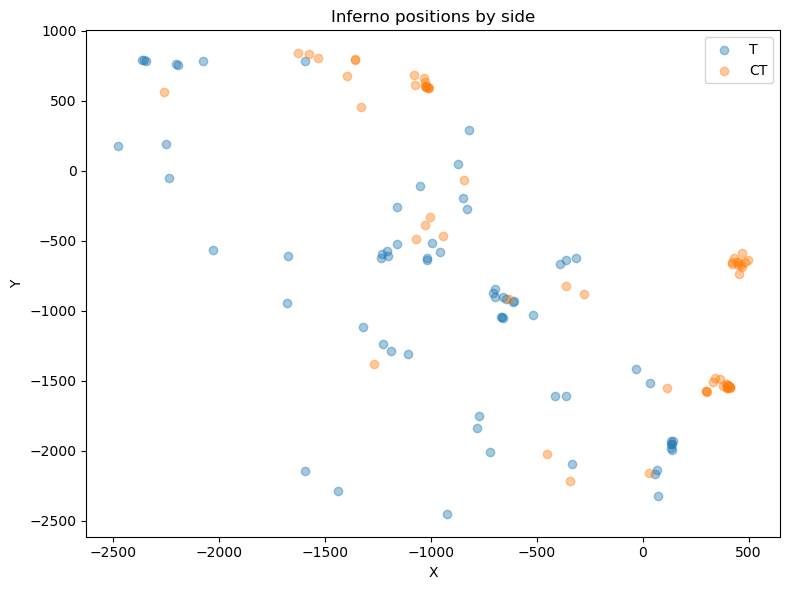

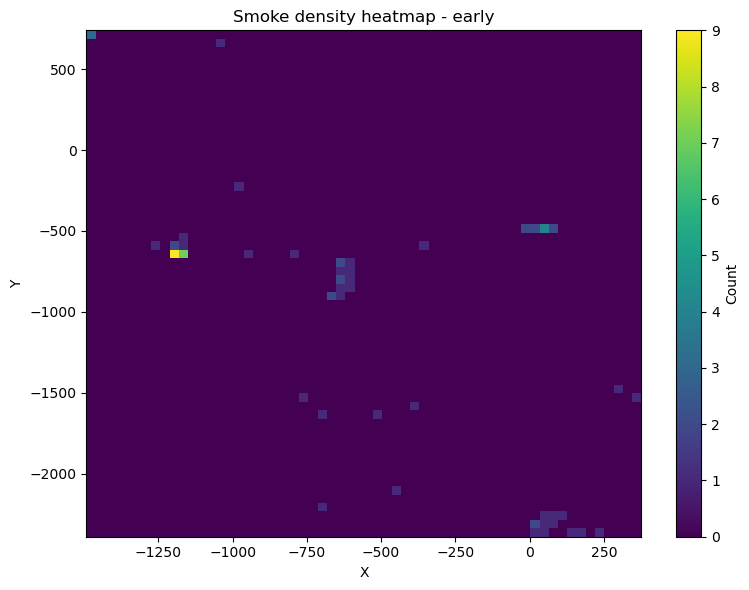

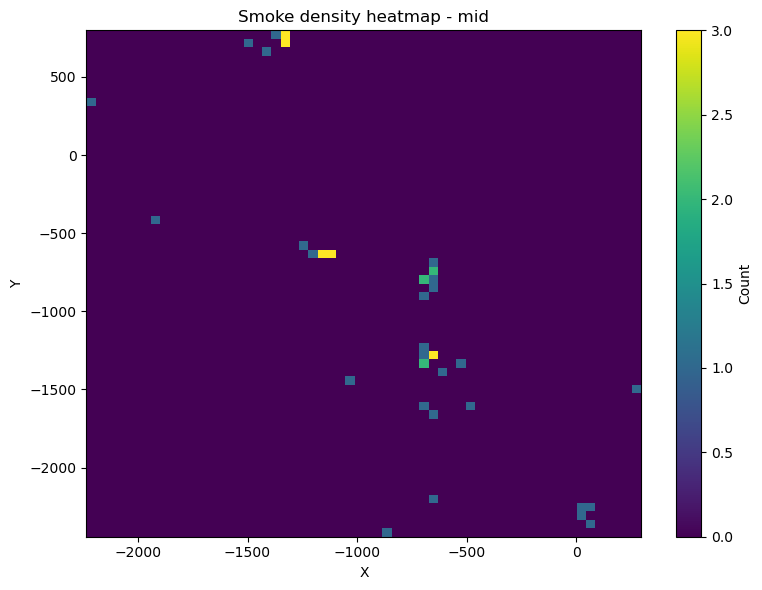

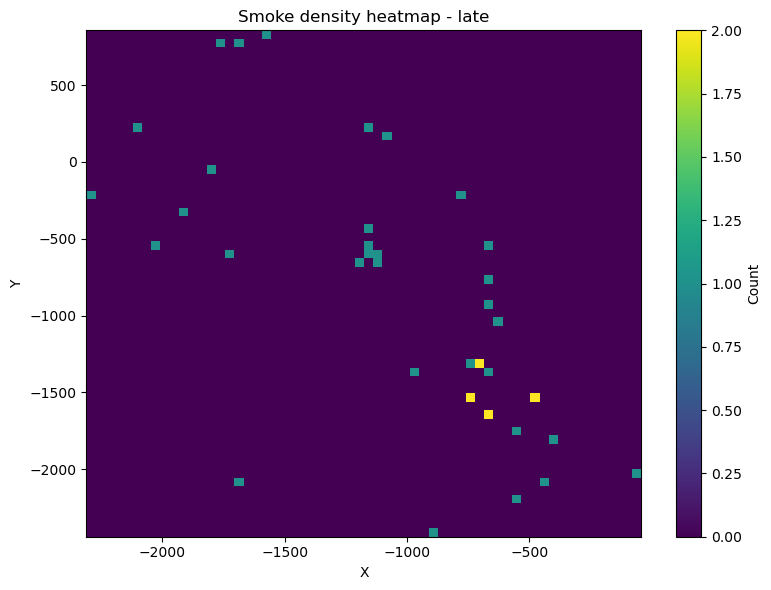

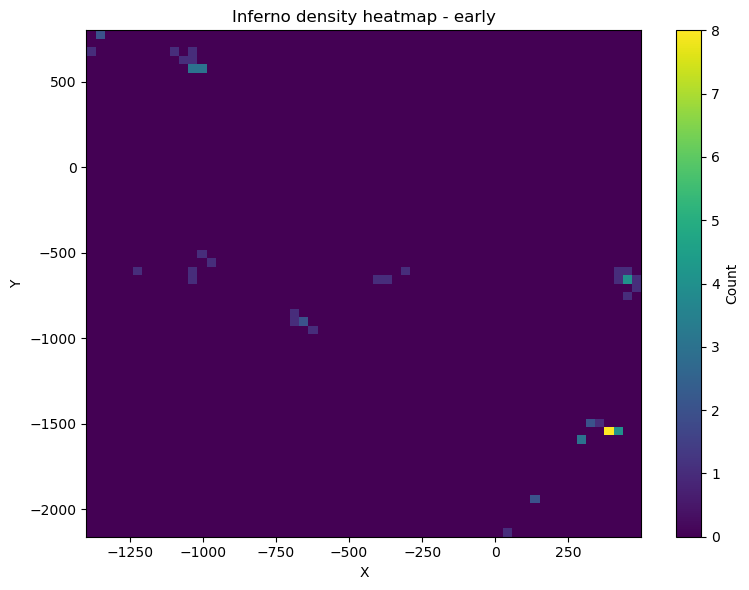

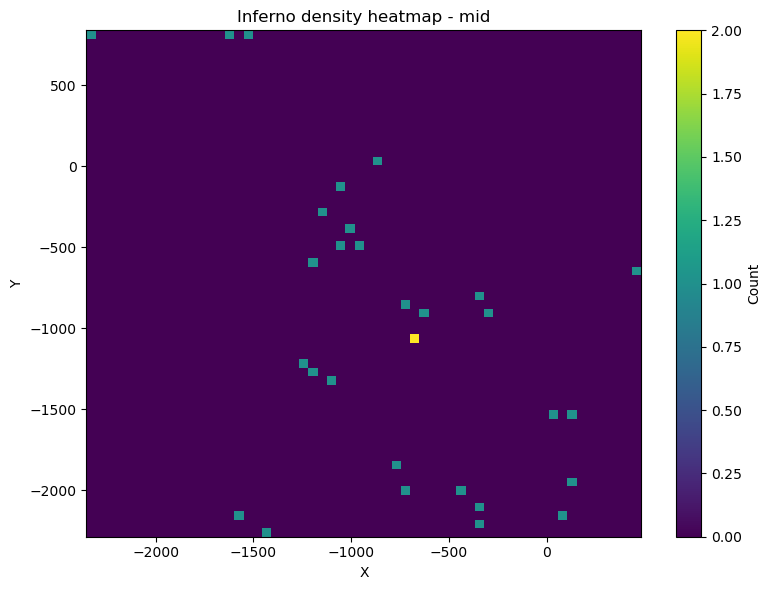

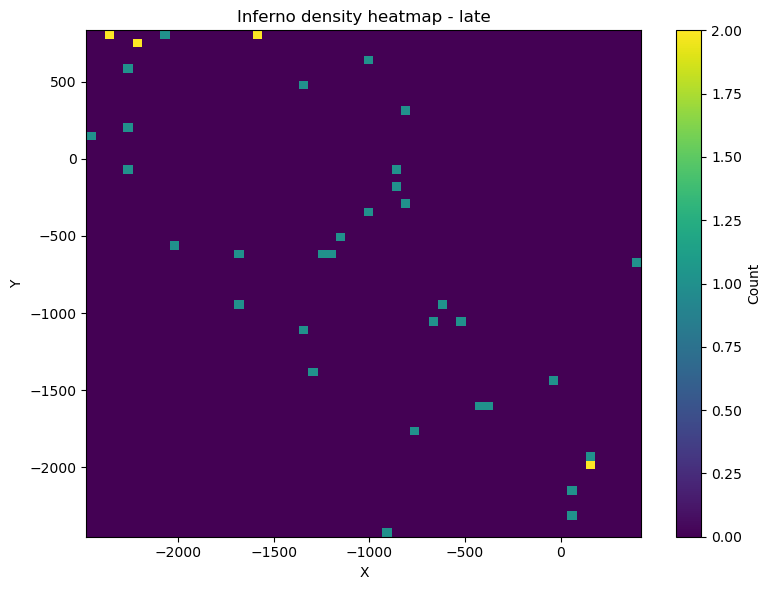

              grenade_type    rows  valid_xy
8  CSmokeGrenadeProjectile  258774    258774
3     CHEGrenadeProjectile   37312     37312
1     CFlashbangProjectile   14040     14040
6       CMolotovProjectile   13886     13886
0               CFlashbang  807002         0
7            CSmokeGrenade  626331         0
2               CHEGrenade  477071         0
5          CMolotovGrenade  358758         0
4       CIncendiaryGrenade  178734         0


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

grenades_pd = dem.grenades.to_pandas().copy()
smokes_pd = dem.smokes.to_pandas().copy()
infernos_pd = dem.infernos.to_pandas().copy()
rounds_pd = dem.rounds.to_pandas().copy()

def clean_xy(df: pd.DataFrame, x_col: str = "X", y_col: str = "Y") -> pd.DataFrame:
    out = df.copy()
    out[x_col] = pd.to_numeric(out[x_col], errors="coerce")
    out[y_col] = pd.to_numeric(out[y_col], errors="coerce")
    out = out[np.isfinite(out[x_col]) & np.isfinite(out[y_col])]
    return out

def safe_hist2d(df: pd.DataFrame, title: str, x_col: str = "X", y_col: str = "Y", bins: int = 60, cbar_label: str = "Count"):
    sub = clean_xy(df, x_col, y_col)
    if sub.empty:
        print(f"Nincs használható koordináta ehhez: {title}")
        return

    plt.figure(figsize=(8, 6))
    plt.hist2d(sub[x_col].to_numpy(), sub[y_col].to_numpy(), bins=bins)
    plt.colorbar(label=cbar_label)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

def safe_scatter_by_side(df: pd.DataFrame, title: str, side_col: str = "thrower_side", x_col: str = "X", y_col: str = "Y"):
    if not all(col in df.columns for col in [side_col, x_col, y_col]):
        print(f"Hiányzó oszlop(ok): {title}")
        return

    sub = clean_xy(df, x_col, y_col)
    if sub.empty:
        print(f"Nincs használható koordináta ehhez: {title}")
        return

    t_sub = sub[sub[side_col].astype(str).str.upper() == "T"]
    ct_sub = sub[sub[side_col].astype(str).str.upper() == "CT"]

    if t_sub.empty and ct_sub.empty:
        print(f"Nincs T vagy CT adat ehhez: {title}")
        return

    plt.figure(figsize=(8, 6))
    if not t_sub.empty:
        plt.scatter(t_sub[x_col], t_sub[y_col], alpha=0.4, label="T")
    if not ct_sub.empty:
        plt.scatter(ct_sub[x_col], ct_sub[y_col], alpha=0.4, label="CT")
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

def add_phase_from_start_tick(df: pd.DataFrame, rounds_df: pd.DataFrame, start_tick_col: str = "start_tick") -> pd.DataFrame:
    if not all(col in df.columns for col in [start_tick_col, "round_num"]):
        return pd.DataFrame()

    if "freeze_end" not in rounds_df.columns:
        return pd.DataFrame()

    out = df.copy()
    round_info = rounds_df[["round_num", "freeze_end"]].dropna().copy()
    round_info["round_num"] = pd.to_numeric(round_info["round_num"], errors="coerce")
    round_info["freeze_end"] = pd.to_numeric(round_info["freeze_end"], errors="coerce")
    round_info = round_info.dropna()

    freeze_map = round_info.set_index("round_num")["freeze_end"].to_dict()

    out[start_tick_col] = pd.to_numeric(out[start_tick_col], errors="coerce")
    out["round_num"] = pd.to_numeric(out["round_num"], errors="coerce")
    out = out.dropna(subset=[start_tick_col, "round_num"])

    out["seconds_since_freeze_end"] = out.apply(
        lambda row: (row[start_tick_col] - freeze_map[row["round_num"]]) / TICKS_PER_SECOND
        if row["round_num"] in freeze_map else np.nan,
        axis=1
    )

    out = out.dropna(subset=["seconds_since_freeze_end"])

    out["phase"] = np.where(
        out["seconds_since_freeze_end"] < 20,
        "early",
        np.where(out["seconds_since_freeze_end"] < 50, "mid", "late")
    )
    return out

# --------------------------------------------------
# 1. Smoke density heatmap
# --------------------------------------------------
if all(col in smokes_pd.columns for col in ["X", "Y"]):
    safe_hist2d(smokes_pd, "Smoke density heatmap")
else:
    print("smokes dataframe-ben nincs X/Y oszlop")

# --------------------------------------------------
# 2. Inferno density heatmap
# --------------------------------------------------
if all(col in infernos_pd.columns for col in ["X", "Y"]):
    safe_hist2d(infernos_pd, "Inferno density heatmap")
else:
    print("infernos dataframe-ben nincs X/Y oszlop")

# --------------------------------------------------
# 3. T vs CT smoke density heatmap
# --------------------------------------------------
if all(col in smokes_pd.columns for col in ["thrower_side", "X", "Y"]):
    for side in ["T", "CT"]:
        sub = smokes_pd[smokes_pd["thrower_side"].astype(str).str.upper() == side].copy()
        safe_hist2d(sub, f"{side} smoke density heatmap")
else:
    print("smokes dataframe-ben nincs thrower_side vagy X/Y oszlop")

# --------------------------------------------------
# 4. Grenade type szerinti utility density heatmap
# --------------------------------------------------
if all(col in grenades_pd.columns for col in ["grenade_type", "X", "Y"]):
    grenade_types = sorted(grenades_pd["grenade_type"].dropna().astype(str).unique())

    for gtype in grenade_types:
        sub = grenades_pd[grenades_pd["grenade_type"].astype(str) == gtype].copy()
        safe_hist2d(sub, f"Utility density: {gtype}")
else:
    print("grenades dataframe-ben nincs grenade_type vagy X/Y oszlop")

# --------------------------------------------------
# 5. T vs CT inferno density heatmap
# --------------------------------------------------
if all(col in infernos_pd.columns for col in ["thrower_side", "X", "Y"]):
    for side in ["T", "CT"]:
        sub = infernos_pd[infernos_pd["thrower_side"].astype(str).str.upper() == side].copy()
        safe_hist2d(sub, f"{side} inferno density heatmap")
else:
    print("infernos dataframe-ben nincs thrower_side vagy X/Y oszlop")

# --------------------------------------------------
# 6. Smoke scatter T vs CT
# --------------------------------------------------
safe_scatter_by_side(smokes_pd, "Smoke positions by side")

# --------------------------------------------------
# 7. Inferno scatter T vs CT
# --------------------------------------------------
safe_scatter_by_side(infernos_pd, "Inferno positions by side")

# --------------------------------------------------
# 8. Round phase szerinti smoke density heatmap
# --------------------------------------------------
smoke_phase_pd = add_phase_from_start_tick(smokes_pd, rounds_pd, start_tick_col="start_tick")
if not smoke_phase_pd.empty and all(col in smoke_phase_pd.columns for col in ["phase", "X", "Y"]):
    for phase in ["early", "mid", "late"]:
        sub = smoke_phase_pd[smoke_phase_pd["phase"] == phase].copy()
        safe_hist2d(sub, f"Smoke density heatmap - {phase}")
else:
    print("Nem sikerült smoke phase adatot előállítani")

# --------------------------------------------------
# 9. Round phase szerinti inferno density heatmap
# --------------------------------------------------
inferno_phase_pd = add_phase_from_start_tick(infernos_pd, rounds_pd, start_tick_col="start_tick")
if not inferno_phase_pd.empty and all(col in inferno_phase_pd.columns for col in ["phase", "X", "Y"]):
    for phase in ["early", "mid", "late"]:
        sub = inferno_phase_pd[inferno_phase_pd["phase"] == phase].copy()
        safe_hist2d(sub, f"Inferno density heatmap - {phase}")
else:
    print("Nem sikerült inferno phase adatot előállítani")

# --------------------------------------------------
# 10. Gyors ellenőrzés: mely grenade type-oknak van használható koordinátája
# --------------------------------------------------
if all(col in grenades_pd.columns for col in ["grenade_type", "X", "Y"]):
    check_rows = []
    for gtype in sorted(grenades_pd["grenade_type"].dropna().astype(str).unique()):
        sub = grenades_pd[grenades_pd["grenade_type"].astype(str) == gtype].copy()
        sub["X"] = pd.to_numeric(sub["X"], errors="coerce")
        sub["Y"] = pd.to_numeric(sub["Y"], errors="coerce")
        valid = np.isfinite(sub["X"]) & np.isfinite(sub["Y"])

        check_rows.append({
            "grenade_type": gtype,
            "rows": len(sub),
            "valid_xy": int(valid.sum())
        })

    grenade_xy_check_df = pd.DataFrame(check_rows).sort_values(["valid_xy", "rows"], ascending=[False, False])
    print(grenade_xy_check_df)